**THIS IS CORRECT** **I WILL BE USING THIS**

**SAME CODE AS ABOVE BUT DIFFERENT LAGS LIKE WEEKLY**

In [ ]:
# ============================================================
# COMPLETE STGCN PIPELINE – LEAKAGE-SAFE, ALL AVAILABLE FEATURES
# FIX: Lags are now weekly (shift(lag*7)) instead of daily
# ============================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import copy
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from torch.utils.data import TensorDataset, DataLoader

# ---------------------------
# 1. LOAD AND CLEAN WEEKLY DATA
# ---------------------------
file_path = "/content/influenza_special_study_dataset.csv"
df = pd.read_csv(file_path)

# Standardise country names
df['country'] = df['country'].replace({
    "Lao People's Democratic Republic": "Lao PDR",
    "Viet Nam": "Vietnam"
})

# Remove Myanmar (only 8 countries)
df = df[df['country'] != 'Myanmar'].copy()

# Keep only 2010-2019 (pre‑COVID, complete)
df = df[(df['year'] >= 2010) & (df['year'] <= 2019)].copy()

# Create proper datetime (Monday of that week)
df['date'] = pd.to_datetime(
    df['year'].astype(str) + '-W' + df['week'].astype(str) + '-1',
    format='%G-W%V-%u'
)
df = df.sort_values(['country', 'date'])

# List of countries
countries = sorted(df['country'].unique())
print("Countries:", countries)

# ---------------------------
# 2. SPLIT WEEKLY DATA CHRONOLOGICALLY
# ---------------------------
train_weekly = df[df['date'] < '2017-01-01'].copy()
val_weekly   = df[(df['date'] >= '2017-01-01') & (df['date'] < '2019-01-01')].copy()
test_weekly  = df[df['date'] >= '2019-01-01'].copy()

print(f"Weekly splits: Train {len(train_weekly)} rows, Val {len(val_weekly)}, Test {len(test_weekly)}")

# ---------------------------
# 3. DEFINE COLUMN GROUPS
# ---------------------------
base_signals = [
    'specimens_tested', 'influenza_positive', 'positivity_rate',
    'temp_weekly_avg', 'humidity_weekly_avg', 'absolute_humidity'
]

candidate_static_cols = [
    'pm25', 'gdp_growth', 'gdp_per_capita', 'hospital_beds_per_1000',
    'life_expectancy', 'physicians_per_1000', 'population_0_14',
    'population_15_64', 'population_above_65', 'population_density'
]
static_cols = [col for col in candidate_static_cols if col in df.columns]
print("Static columns used:", static_cols)

# ---------------------------
# 4. FUNCTION: WEEKLY -> DAILY (interpolate only base signals)
# ---------------------------
def weekly_to_daily_base(df_weekly_subset, base_signals):
    countries = df_weekly_subset['country'].unique()
    start_date = df_weekly_subset['date'].min()
    end_date   = df_weekly_subset['date'].max()
    daily_idx = pd.date_range(start=start_date, end=end_date, freq='D')
    daily_rows = []
    for c in countries:
        df_c = df_weekly_subset[df_weekly_subset['country'] == c][['date'] + base_signals].set_index('date')
        df_daily = df_c.reindex(daily_idx)
        df_daily[base_signals] = df_daily[base_signals].interpolate(method='linear', limit_area='inside')
        df_daily['country'] = c
        df_daily['year'] = df_daily.index.year
        df_daily['month'] = df_daily.index.month
        df_daily['week'] = df_daily.index.isocalendar().week.astype(int)
        day_of_year = df_daily.index.dayofyear
        df_daily['sin_week'] = np.sin(2 * np.pi * day_of_year / 365.25)
        df_daily['cos_week'] = np.cos(2 * np.pi * day_of_year / 365.25)
        df_reset = df_daily.reset_index().rename(columns={'index': 'date'})
        daily_rows.append(df_reset)
    return pd.concat(daily_rows, ignore_index=True)

df_daily_train_base = weekly_to_daily_base(train_weekly, base_signals)
df_daily_val_base   = weekly_to_daily_base(val_weekly,   base_signals)
df_daily_test_base  = weekly_to_daily_base(test_weekly,  base_signals)

# ---------------------------
# 5. ADD STATIC FEATURES
# ---------------------------
def add_static_features(df_daily_base, df_weekly_split, static_cols):
    weekly_static = df_weekly_split[['date', 'country'] + static_cols].copy()
    df_daily = df_daily_base.merge(weekly_static, on=['date', 'country'], how='left')
    df_daily[static_cols] = df_daily.groupby('country')[static_cols].ffill().bfill()
    return df_daily

df_daily_train = add_static_features(df_daily_train_base, train_weekly, static_cols)
df_daily_val   = add_static_features(df_daily_val_base,   val_weekly,   static_cols)
df_daily_test  = add_static_features(df_daily_test_base,  test_weekly,  static_cols)

print(f"Daily shapes after static: Train {df_daily_train.shape}, Val {df_daily_val.shape}, Test {df_daily_test.shape}")

# ---------------------------
# 6. ADD LAG AND ROLLING FEATURES (FIX: weekly lags)
# ---------------------------
def add_lag_rolling(df_daily):
    df = df_daily.sort_values(['country', 'date']).copy()
    # Lags are now weekly: shift by 7,14,21,28 days
    for lag in range(1, 5):
        df[f'flu_lag_{lag}'] = df.groupby('country')['positivity_rate'].shift(lag * 7)
    # Rolling mean and std (3-day, using only past)
    df['rolling_mean_3'] = df.groupby('country')['positivity_rate'].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean()
    )
    df['rolling_std_3'] = df.groupby('country')['positivity_rate'].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).std()
    ).fillna(0)
    lag_cols = [f'flu_lag_{l}' for l in range(1,5)] + ['rolling_mean_3']
    df = df.dropna(subset=lag_cols).reset_index(drop=True)
    return df

df_daily_train = add_lag_rolling(df_daily_train)
df_daily_val   = add_lag_rolling(df_daily_val)
df_daily_test  = add_lag_rolling(df_daily_test)

print(f"After adding lags: Train {df_daily_train.shape}, Val {df_daily_val.shape}, Test {df_daily_test.shape}")

# ---------------------------
# 7. DEFINE INPUT FEATURES
# ---------------------------
input_feature_cols = [
    'flu_lag_1', 'flu_lag_2', 'flu_lag_3', 'flu_lag_4',
    'rolling_mean_3', 'rolling_std_3',
    'temp_weekly_avg', 'humidity_weekly_avg', 'absolute_humidity',
    'sin_week', 'cos_week'
] + static_cols

target_col = 'positivity_rate'
print(f"Number of input features: {len(input_feature_cols)}")

# ---------------------------
# 8. BUILD TENSORS
# ---------------------------
def build_tensor(df_daily, countries, input_features, target_col):
    df_daily = df_daily.sort_values(['date', 'country']).reset_index(drop=True)
    all_dates = sorted(df_daily['date'].unique())
    n_dates = len(all_dates)
    n_nodes = len(countries)
    n_feat = len(input_features)
    X_raw = np.zeros((n_dates, n_nodes, n_feat), dtype=np.float32)
    Y_raw = np.zeros((n_dates, n_nodes), dtype=np.float32)
    date_to_idx = {d: i for i, d in enumerate(all_dates)}
    country_to_idx = {c: i for i, c in enumerate(countries)}
    for _, row in df_daily.iterrows():
        t = date_to_idx[row['date']]
        c = country_to_idx[row['country']]
        X_raw[t, c, :] = row[input_features].values
        Y_raw[t, c] = row[target_col]
    return X_raw, Y_raw, all_dates

X_train_raw, Y_train_raw, train_dates = build_tensor(df_daily_train, countries, input_feature_cols, target_col)
X_val_raw,   Y_val_raw,   val_dates   = build_tensor(df_daily_val,   countries, input_feature_cols, target_col)
X_test_raw,  Y_test_raw,  test_dates  = build_tensor(df_daily_test,  countries, input_feature_cols, target_col)

print(f"Raw tensors: Train {X_train_raw.shape}, Val {X_val_raw.shape}, Test {X_test_raw.shape}")

# ---------------------------
# 9. CREATE SLIDING WINDOWS (14 days input, 1 day ahead)
# ---------------------------
def create_sequences(X_raw, Y_raw, dates, input_window=14, horizon=1):
    X_seq, y_seq, target_dates = [], [], []
    for t in range(len(X_raw) - input_window - horizon + 1):
        x_window = X_raw[t:t+input_window]
        x_window = np.transpose(x_window, (1, 0, 2))
        y_target = Y_raw[t+input_window+horizon-1, :]
        X_seq.append(x_window)
        y_seq.append(y_target)
        target_dates.append(dates[t+input_window+horizon-1])
    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32), target_dates

input_window = 14
horizon = 1
X_train, y_train, train_target_dates = create_sequences(X_train_raw, Y_train_raw, train_dates, input_window, horizon)
X_val,   y_val,   val_target_dates   = create_sequences(X_val_raw,   Y_val_raw,   val_dates,   input_window, horizon)
X_test,  y_test,  test_target_dates  = create_sequences(X_test_raw,  Y_test_raw,  test_dates,  input_window, horizon)

print(f"Sequence shapes: Train {X_train.shape}, Val {X_val.shape}, Test {X_test.shape}")

# ---------------------------
# 10. SCALE X (features)
# ---------------------------
n_samples, n_nodes, seq_len, n_feat = X_train.shape
X_train_flat = X_train.transpose(0,2,1,3).reshape(-1, n_feat)
x_scaler = StandardScaler()
x_scaler.fit(X_train_flat)

def scale_X(X, scaler):
    n_s, n_n, seq, n_f = X.shape
    X_flat = X.transpose(0,2,1,3).reshape(-1, n_f)
    X_scaled = scaler.transform(X_flat)
    return X_scaled.reshape(n_s, seq, n_n, n_f).transpose(0,2,1,3)

X_train_scaled = scale_X(X_train, x_scaler)
X_val_scaled   = scale_X(X_val,   x_scaler)
X_test_scaled  = scale_X(X_test,  x_scaler)

# ---------------------------
# 11. SCALE y (target) per country
# ---------------------------
y_scalers = {}
y_train_scaled = np.zeros_like(y_train)
y_val_scaled   = np.zeros_like(y_val)
y_test_scaled  = np.zeros_like(y_test)

for i, c in enumerate(countries):
    scaler = StandardScaler()
    y_train_scaled[:, i:i+1] = scaler.fit_transform(y_train[:, i:i+1])
    y_val_scaled[:, i:i+1]   = scaler.transform(y_val[:, i:i+1])
    y_test_scaled[:, i:i+1]  = scaler.transform(y_test[:, i:i+1])
    y_scalers[c] = scaler

# Clean any NaNs (safety)
X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0)
y_train_scaled = np.nan_to_num(y_train_scaled, nan=0.0)
X_val_scaled   = np.nan_to_num(X_val_scaled,   nan=0.0)
y_val_scaled   = np.nan_to_num(y_val_scaled,   nan=0.0)
X_test_scaled  = np.nan_to_num(X_test_scaled,  nan=0.0)
y_test_scaled  = np.nan_to_num(y_test_scaled,  nan=0.0)

# ---------------------------
# 12. DATALOADERS
# ---------------------------
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_scaled,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val_scaled,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test_scaled,  dtype=torch.float32)

batch_size = 64
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

# ---------------------------
# 13. LOAD INITIAL ADJACENCY MATRIX
# ---------------------------
adj_df = pd.read_csv("/content/final_hybrid_adjacency_matrix_8countries.csv", index_col=0)
W_initial = torch.tensor(adj_df.values, dtype=torch.float32)

# ---------------------------
# 14. STGCN MODEL (trainable adjacency)
# ---------------------------
class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.pad = nn.ConstantPad2d((0, 0, 2, 0), 0)
        self.conv_filter = nn.Conv2d(in_channels, out_channels, kernel_size=(3, 1))
        self.conv_gate   = nn.Conv2d(in_channels, out_channels, kernel_size=(3, 1))

    def forward(self, x):
        x_padded = self.pad(x)
        filt = self.conv_filter(x_padded)
        gate = torch.sigmoid(self.conv_gate(x_padded))
        return filt * gate

class GraphConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.linear = nn.Linear(in_channels, out_channels)

    def forward(self, x, A):
        x = torch.einsum("ij,btjf->btif", A, x)
        return self.linear(x)

class STGCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.3):
        super().__init__()
        self.temp1 = TemporalBlock(in_channels, out_channels)
        self.graph = GraphConv(out_channels, out_channels)
        self.temp2 = TemporalBlock(out_channels, out_channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, A):
        x = self.temp1(x)
        x = x.permute(0, 2, 3, 1)
        x = F.relu(self.graph(x, A))
        x = x.permute(0, 3, 1, 2)
        x = self.temp2(x)
        return self.dropout(x)

class STGCN(nn.Module):
    def __init__(self, num_nodes, in_channels, W_initial, hidden_channels=64, dropout=0.3):
        super().__init__()
        self.A_adaptive = nn.Parameter(W_initial.clone())
        self.block1 = STGCNBlock(in_channels, hidden_channels, dropout)
        self.block2 = STGCNBlock(hidden_channels, hidden_channels, dropout)
        self.final_temp = TemporalBlock(hidden_channels, hidden_channels)
        self.fc = nn.Linear(hidden_channels, 1)

    def forward(self, x):
        A = F.relu(self.A_adaptive)
        A = 0.5 * (A + A.T)
        x = x.permute(0, 3, 2, 1)
        x = self.block1(x, A)
        x = self.block2(x, A)
        x = self.final_temp(x)
        x = x[:, :, -1, :]
        x = x.permute(0, 2, 1)
        out = self.fc(x).squeeze(-1)
        return out

# ---------------------------
# 15. TRAINING
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = STGCN(
    num_nodes=len(countries),
    in_channels=len(input_feature_cols),
    W_initial=W_initial.to(device),
    hidden_channels=64,
    dropout=0.3
).to(device)

criterion = nn.HuberLoss(delta=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

num_epochs = 60
patience = 15
best_val_loss = float('inf')
best_state = None
patience_counter = 0

print("\n🚀 Training STGCN (weekly lags, trainable graph, anchor evaluation)...")
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = criterion(model(xb), yb)
            val_loss += loss.item()
    val_loss /= len(val_loader)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

model.load_state_dict(best_state)
print(f"✅ Best validation loss: {best_val_loss:.6f}")

# ---------------------------
# 16. EVALUATION ON WEEKLY ANCHOR DATES
# ---------------------------
model.eval()
all_preds_scaled = []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        preds = model(xb).cpu().numpy()
        all_preds_scaled.append(preds)
y_pred_scaled = np.concatenate(all_preds_scaled, axis=0)

y_pred_raw = np.zeros_like(y_pred_scaled)
for i, c in enumerate(countries):
    y_pred_raw[:, i:i+1] = y_scalers[c].inverse_transform(y_pred_scaled[:, i:i+1])

test_dates = test_target_dates
pred_rows = []
for d_idx, dt in enumerate(test_dates):
    for c_idx, c in enumerate(countries):
        pred_rows.append({
            "date": pd.to_datetime(dt),
            "country": c,
            "stgcn_pred": y_pred_raw[d_idx, c_idx]
        })
df_pred_daily = pd.DataFrame(pred_rows)

weekly_true = test_weekly[["date", "country", "positivity_rate"]].copy()
df_eval = weekly_true.merge(df_pred_daily, on=["date", "country"], how="inner")

y_true = df_eval["positivity_rate"].values
y_pred = df_eval["stgcn_pred"].values

print("\n🌟 FINAL ANCHOR-DATE EVALUATION 🌟")
print(f"Matched {len(df_eval)} weekly anchor dates.")
print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")
print(f"MAE : {mean_absolute_error(y_true, y_pred):.4f}")
print(f"Overall R² : {r2_score(y_true, y_pred):.4f}\n")

print("--- Country-level R² ---")
for c in countries:
    sub = df_eval[df_eval["country"] == c]
    if len(sub) > 1:
        r2_c = r2_score(sub["positivity_rate"], sub["stgcn_pred"])
        print(f"{c:12s} R² = {r2_c:.4f}")

Countries: ['Cambodia', 'Indonesia', 'Lao PDR', 'Malaysia', 'Philippines', 'Singapore', 'Thailand', 'Vietnam']
Weekly splits: Train 2819 rows, Val 829, Test 404
Static columns used: ['pm25', 'gdp_growth', 'gdp_per_capita', 'hospital_beds_per_1000', 'life_expectancy', 'physicians_per_1000', 'population_0_14', 'population_15_64', 'population_above_65', 'population_density']
Daily shapes after static: Train (20392, 23), Val (5832, 23), Test (2808, 23)
After adding lags: Train (20118, 29), Val (5597, 29), Test (2562, 29)
Number of input features: 21
Raw tensors: Train (2521, 8, 21), Val (701, 8, 21), Test (323, 8, 21)
Sequence shapes: Train (2507, 8, 14, 21), Val (687, 8, 14, 21), Test (309, 8, 14, 21)

🚀 Training STGCN (weekly lags, trainable graph, anchor evaluation)...
Epoch 01 | Train Loss: 0.0642 | Val Loss: 0.0695
Epoch 05 | Train Loss: 0.0264 | Val Loss: 0.0402
Epoch 10 | Train Loss: 0.0147 | Val Loss: 0.0287
Epoch 15 | Train Loss: 0.0113 | Val Loss: 0.0236
Epoch 20 | Train Loss: 0.

**BASELINE TRAINING ON DAILY DATA**

In [ ]:
import pandas as pd
import numpy as np

file_path = "/content/influenza_special_study_dataset.csv"
df = pd.read_csv(file_path)

# Standardize names
df['country'] = df['country'].replace({
    "Lao People's Democratic Republic": "Lao PDR",
    "Viet Nam": "Vietnam"
})

# Remove Myanmar
df = df[df['country'] != 'Myanmar'].copy()

# Keep 2010–2019
df = df[(df['year'] >= 2010) & (df['year'] <= 2019)].copy()

# Create date
df['date'] = pd.to_datetime(
    df['year'].astype(str) + '-W' + df['week'].astype(str) + '-1',
    format='%G-W%V-%u'
)

df = df.sort_values(['country', 'date'])

In [ ]:
train_weekly = df[df['date'] < '2017-01-01'].copy()
val_weekly   = df[(df['date'] >= '2017-01-01') & (df['date'] < '2019-01-01')].copy()
test_weekly  = df[df['date'] >= '2019-01-01'].copy()

In [ ]:
base_signals = [
    'specimens_tested', 'influenza_positive', 'positivity_rate',
    'temp_weekly_avg', 'humidity_weekly_avg', 'absolute_humidity'
]

static_cols = [
    'pm25', 'gdp_growth', 'gdp_per_capita', 'hospital_beds_per_1000',
    'life_expectancy', 'physicians_per_1000',
    'population_0_14', 'population_15_64',
    'population_above_65', 'population_density'
]

def weekly_to_daily(df_weekly):
    countries = df_weekly['country'].unique()
    daily_rows = []

    for c in countries:
        df_c = df_weekly[df_weekly['country'] == c].set_index('date')

        idx = pd.date_range(df_c.index.min(), df_c.index.max(), freq='D')
        df_daily = df_c.reindex(idx)

        # Interpolate signals
        df_daily[base_signals] = df_daily[base_signals].interpolate()

        # Fill static
        df_daily[static_cols] = df_daily[static_cols].ffill().bfill()

        df_daily['country'] = c
        df_daily['date'] = df_daily.index

        df_daily['year'] = df_daily.index.year
        df_daily['month'] = df_daily.index.month
        df_daily['week'] = df_daily.index.isocalendar().week.astype(int)

        # Seasonal encoding
        d = df_daily.index.dayofyear
        df_daily['sin_week'] = np.sin(2*np.pi*d/365.25)
        df_daily['cos_week'] = np.cos(2*np.pi*d/365.25)

        daily_rows.append(df_daily.reset_index(drop=True))

    return pd.concat(daily_rows, ignore_index=True)

train_daily = weekly_to_daily(train_weekly)
val_daily   = weekly_to_daily(val_weekly)
test_daily  = weekly_to_daily(test_weekly)

In [ ]:
def add_features(df):
    df = df.sort_values(['country', 'date'])

    # Weekly lags
    for lag in range(1, 5):
        df[f'flu_lag_{lag}'] = df.groupby('country')['positivity_rate'].shift(lag*7)

    # Rolling
    df['rolling_mean_3'] = df.groupby('country')['positivity_rate'].transform(
        lambda x: x.shift(1).rolling(3).mean()
    )

    df['rolling_std_3'] = df.groupby('country')['positivity_rate'].transform(
        lambda x: x.shift(1).rolling(3).std()
    ).fillna(0)

    return df.dropna().reset_index(drop=True)

train_daily = add_features(train_daily)
val_daily   = add_features(val_daily)
test_daily  = add_features(test_daily)

In [ ]:
feature_cols = [
    'flu_lag_1','flu_lag_2','flu_lag_3','flu_lag_4',
    'rolling_mean_3','rolling_std_3',
    'temp_weekly_avg','humidity_weekly_avg','absolute_humidity',
    'sin_week','cos_week'
] + static_cols

target_col = 'positivity_rate'

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb
import lightgbm as lgb

X_train = train_daily[feature_cols]
y_train = train_daily[target_col]

X_test = test_daily[feature_cols]
y_test = test_daily[target_col]

rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

xgb_model = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6)
xgb_model.fit(X_train, y_train)

lgb_model = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05)
lgb_model.fit(X_train, y_train)

LGBMRegressor(learning_rate=0.05, n_estimators=300)

In [ ]:
test_daily['rf_pred'] = rf.predict(X_test)
test_daily['xgb_pred'] = xgb_model.predict(X_test)
test_daily['lgb_pred'] = lgb_model.predict(X_test)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# BASELINE EXPERIMENT: Train on Daily -> Evaluate on Weekly
# ============================================================

# 1. Define Target and Extract Features Dynamically
target = 'positivity_rate'

# Automatically grab all feature columns (ignores dates, identifiers, and the target)
features = [col for col in df_daily_train.columns if col not in ['date', 'country', target, 'iso_year', 'iso_week']]
print(f"✅ Extracted {len(features)} features for training.")

# 2. Prepare Training Data (Daily Interpolated)
# Tree models cannot handle NaNs in features, so we drop any missing rows (like initial lags)
train_data = df_daily_train.dropna(subset=features + [target]).copy()
X_train_daily = train_data[features]
y_train_daily = train_data[target]

# Prepare Testing Data (Daily Interpolated)
test_data = df_daily_test.dropna(subset=features + [target]).copy()
X_test_daily = test_data[features]
y_test_daily = test_data[target]

print(f"✅ Training data shape: {X_train_daily.shape}")
print(f"✅ Testing data shape: {X_test_daily.shape}")

# 3. Initialize Models (random_state ensures your thesis results don't change)
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
lgb_model = lgb.LGBMRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, verbose=-1)

# 4. Train Models strictly on DAILY data
print("\n🚀 Training baselines on daily interpolated data...")
rf.fit(X_train_daily, y_train_daily)
print("   - RF Trained.")
xgb_model.fit(X_train_daily, y_train_daily)
print("   - XGBoost Trained.")
lgb_model.fit(X_train_daily, y_train_daily)
print("   - LightGBM Trained.")

# 5. Predict on DAILY test data
test_data['rf_pred'] = rf.predict(X_test_daily)
test_data['xgb_pred'] = xgb_model.predict(X_test_daily)
test_data['lgb_pred'] = lgb_model.predict(X_test_daily)

# 6. Evaluate strictly on WEEKLY Anchor Dates
# Extract only the necessary columns from the daily predictions
daily_preds = test_data[['date', 'country', 'rf_pred', 'xgb_pred', 'lgb_pred']].copy()

# CRITICAL SAFETY STEP: Force datetime formats to match exactly so the merge works
daily_preds['date'] = pd.to_datetime(daily_preds['date'])
test_weekly_eval = test_weekly.copy()
test_weekly_eval['date'] = pd.to_datetime(test_weekly_eval['date'])

def evaluate_on_anchor_dates(pred_col, model_name):
    # This 'inner' merge is the core of your RQ!
    # It throws away all the interpolated days and only keeps the real weekly dates.
    df_eval = test_weekly_eval[['date', 'country', 'positivity_rate']].merge(
        daily_preds,
        on=['date', 'country'],
        how='inner'
    )

    # Drop any remaining NaNs just in case
    df_eval = df_eval.dropna(subset=['positivity_rate', pred_col])

    y_true = df_eval['positivity_rate']
    y_pred = df_eval[pred_col]

    print(f"\n🌟 {model_name} (Train: Daily -> Test: Weekly Anchor)")
    print(f"   Matched {len(df_eval)} weekly anchor dates.")
    print(f"   RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")
    print(f"   MAE : {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"   R²  : {r2_score(y_true, y_pred):.4f}")

# Run the evaluation
print("\n--- FINAL EVALUATION RESULTS ---")
evaluate_on_anchor_dates('rf_pred', "Random Forest")
evaluate_on_anchor_dates('xgb_pred', "XGBoost")
evaluate_on_anchor_dates('lgb_pred', "LightGBM")

✅ Extracted 21 features for training.
✅ Training data shape: (17843, 21)
✅ Testing data shape: (1755, 21)

🚀 Training baselines on daily interpolated data...
   - RF Trained.
   - XGBoost Trained.
   - LightGBM Trained.

--- FINAL EVALUATION RESULTS ---

🌟 Random Forest (Train: Daily -> Test: Weekly Anchor)
   Matched 252 weekly anchor dates.
   RMSE: 0.0591
   MAE : 0.0278
   R²  : 0.8217

🌟 XGBoost (Train: Daily -> Test: Weekly Anchor)
   Matched 252 weekly anchor dates.
   RMSE: 0.0385
   MAE : 0.0213
   R²  : 0.9243

🌟 LightGBM (Train: Daily -> Test: Weekly Anchor)
   Matched 252 weekly anchor dates.
   RMSE: 0.0312
   MAE : 0.0171
   R²  : 0.9502


**ABLATION STUDIES (Wgeo and Wlag)**

In [ ]:
# ============================================================
# STGCN ABLATION STUDY (ADAPTIVE ONLY)
# Geo-initialized vs Lag-initialized (Combined excluded)
# 3 seeds each, mean ± std
# ============================================================

import os
import random
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from torch.utils.data import TensorDataset, DataLoader

# ============================================================
# 0. REPRODUCIBILITY
# ============================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ============================================================
# 1. FILE PATHS
# ============================================================

DATA_PATH = "/content/influenza_special_study_dataset.csv"
W_GEO_PATH = "/content/W_geo_8countries.csv"
W_LAG_PATH = "/content/W_lag_8countries.csv"


# ============================================================
# 2. LOAD AND CLEAN WEEKLY DATA
# ============================================================

df = pd.read_csv(DATA_PATH)

df["country"] = df["country"].replace({
    "Lao People's Democratic Republic": "Lao PDR",
    "Viet Nam": "Vietnam"
})

df = df[df["country"] != "Myanmar"].copy()
df = df[(df["year"] >= 2010) & (df["year"] <= 2019)].copy()

df["date"] = pd.to_datetime(
    df["year"].astype(str) + "-W" + df["week"].astype(str) + "-1",
    format="%G-W%V-%u"
)

df = df.sort_values(["country", "date"]).reset_index(drop=True)

countries = sorted(df["country"].unique())
print("Countries:", countries)
print("Shape after cleaning:", df.shape)


# ============================================================
# 3. CHRONOLOGICAL SPLIT
# ============================================================

train_weekly = df[df["date"] < "2017-01-01"].copy()
val_weekly   = df[(df["date"] >= "2017-01-01") & (df["date"] < "2019-01-01")].copy()
test_weekly  = df[df["date"] >= "2019-01-01"].copy()

print(f"Weekly splits -> Train: {train_weekly.shape}, Val: {val_weekly.shape}, Test: {test_weekly.shape}")


# ============================================================
# 4. DEFINE FEATURES
# ============================================================

base_signals = [
    "specimens_tested",
    "influenza_positive",
    "positivity_rate",
    "temp_weekly_avg",
    "humidity_weekly_avg",
    "absolute_humidity"
]

candidate_static_cols = [
    "pm25",
    "gdp_growth",
    "gdp_per_capita",
    "hospital_beds_per_1000",
    "life_expectancy",
    "physicians_per_1000",
    "population_0_14",
    "population_15_64",
    "population_above_65",
    "population_density"
]

static_cols = [col for col in candidate_static_cols if col in df.columns]
print("Static columns used:", static_cols)


# ============================================================
# 5. WEEKLY TO DAILY INTERPOLATION
# ============================================================

def weekly_to_daily_base(df_weekly_subset, base_signals):
    countries_local = df_weekly_subset["country"].unique()
    start_date = df_weekly_subset["date"].min()
    end_date = df_weekly_subset["date"].max()

    daily_idx = pd.date_range(start=start_date, end=end_date, freq="D")
    daily_rows = []

    for c in countries_local:
        df_c = (
            df_weekly_subset[df_weekly_subset["country"] == c][["date"] + base_signals]
            .set_index("date")
        )

        df_daily = df_c.reindex(daily_idx)

        df_daily[base_signals] = df_daily[base_signals].interpolate(
            method="linear",
            limit_area="inside"
        )

        df_daily["country"] = c
        df_daily["year"] = df_daily.index.year
        df_daily["month"] = df_daily.index.month
        df_daily["week"] = df_daily.index.isocalendar().week.astype(int)

        day_of_year = df_daily.index.dayofyear
        df_daily["sin_week"] = np.sin(2 * np.pi * day_of_year / 365.25)
        df_daily["cos_week"] = np.cos(2 * np.pi * day_of_year / 365.25)

        df_daily = df_daily.reset_index().rename(columns={"index": "date"})
        daily_rows.append(df_daily)

    return pd.concat(daily_rows, ignore_index=True)


df_daily_train_base = weekly_to_daily_base(train_weekly, base_signals)
df_daily_val_base   = weekly_to_daily_base(val_weekly, base_signals)
df_daily_test_base  = weekly_to_daily_base(test_weekly, base_signals)

print("Daily base shapes:")
print("Train:", df_daily_train_base.shape)
print("Val  :", df_daily_val_base.shape)
print("Test :", df_daily_test_base.shape)


# ============================================================
# 6. ADD STATIC FEATURES
# ============================================================

def add_static_features(df_daily_base, df_weekly_split, static_cols):
    if len(static_cols) == 0:
        return df_daily_base.copy()

    weekly_static = df_weekly_split[["date", "country"] + static_cols].copy()
    df_daily = df_daily_base.merge(weekly_static, on=["date", "country"], how="left")
    df_daily[static_cols] = df_daily.groupby("country")[static_cols].ffill().bfill()
    return df_daily


df_daily_train = add_static_features(df_daily_train_base, train_weekly, static_cols)
df_daily_val   = add_static_features(df_daily_val_base, val_weekly, static_cols)
df_daily_test  = add_static_features(df_daily_test_base, test_weekly, static_cols)

print("After static features:")
print("Train:", df_daily_train.shape)
print("Val  :", df_daily_val.shape)
print("Test :", df_daily_test.shape)


# ============================================================
# 7. ADD LAG AND ROLLING FEATURES
# ============================================================

def add_lag_rolling(df_daily):
    df_local = df_daily.sort_values(["country", "date"]).copy()

    for lag in range(1, 5):
        df_local[f"flu_lag_{lag}"] = df_local.groupby("country")["positivity_rate"].shift(lag * 7)

    df_local["rolling_mean_3"] = df_local.groupby("country")["positivity_rate"].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean()
    )

    df_local["rolling_std_3"] = df_local.groupby("country")["positivity_rate"].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).std()
    ).fillna(0)

    lag_cols = [f"flu_lag_{l}" for l in range(1, 5)] + ["rolling_mean_3"]
    df_local = df_local.dropna(subset=lag_cols).reset_index(drop=True)

    return df_local


df_daily_train = add_lag_rolling(df_daily_train)
df_daily_val   = add_lag_rolling(df_daily_val)
df_daily_test  = add_lag_rolling(df_daily_test)

print("After lag/rolling features:")
print("Train:", df_daily_train.shape)
print("Val  :", df_daily_val.shape)
print("Test :", df_daily_test.shape)


# ============================================================
# 8. INPUT FEATURES
# ============================================================

input_feature_cols = [
    "flu_lag_1", "flu_lag_2", "flu_lag_3", "flu_lag_4",
    "rolling_mean_3", "rolling_std_3",
    "temp_weekly_avg", "humidity_weekly_avg", "absolute_humidity",
    "sin_week", "cos_week"
] + static_cols

target_col = "positivity_rate"

print("Number of input features:", len(input_feature_cols))


# ============================================================
# 9. BUILD TENSORS
# ============================================================

def build_tensor(df_daily, countries, input_features, target_col):
    df_daily = df_daily.sort_values(["date", "country"]).reset_index(drop=True)

    all_dates = sorted(df_daily["date"].unique())
    n_dates = len(all_dates)
    n_nodes = len(countries)
    n_feat = len(input_features)

    X_raw = np.zeros((n_dates, n_nodes, n_feat), dtype=np.float32)
    Y_raw = np.zeros((n_dates, n_nodes), dtype=np.float32)

    date_to_idx = {d: i for i, d in enumerate(all_dates)}
    country_to_idx = {c: i for i, c in enumerate(countries)}

    for _, row in df_daily.iterrows():
        t = date_to_idx[row["date"]]
        c = country_to_idx[row["country"]]
        X_raw[t, c, :] = row[input_features].values
        Y_raw[t, c] = row[target_col]

    return X_raw, Y_raw, all_dates


X_train_raw, Y_train_raw, train_dates = build_tensor(df_daily_train, countries, input_feature_cols, target_col)
X_val_raw,   Y_val_raw,   val_dates   = build_tensor(df_daily_val, countries, input_feature_cols, target_col)
X_test_raw,  Y_test_raw,  test_dates  = build_tensor(df_daily_test, countries, input_feature_cols, target_col)

print("Raw tensor shapes:")
print("Train:", X_train_raw.shape, Y_train_raw.shape)
print("Val  :", X_val_raw.shape, Y_val_raw.shape)
print("Test :", X_test_raw.shape, Y_test_raw.shape)


# ============================================================
# 10. CREATE SEQUENCES
# ============================================================

def create_sequences(X_raw, Y_raw, dates, input_window=14, horizon=1):
    X_seq, y_seq, target_dates = [], [], []

    for t in range(len(X_raw) - input_window - horizon + 1):
        x_window = X_raw[t:t+input_window]
        x_window = np.transpose(x_window, (1, 0, 2))
        y_target = Y_raw[t+input_window+horizon-1, :]
        X_seq.append(x_window)
        y_seq.append(y_target)
        target_dates.append(dates[t+input_window+horizon-1])

    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32), target_dates


input_window = 14
horizon = 1

X_train, y_train, train_target_dates = create_sequences(X_train_raw, Y_train_raw, train_dates, input_window, horizon)
X_val,   y_val,   val_target_dates   = create_sequences(X_val_raw, Y_val_raw, val_dates, input_window, horizon)
X_test,  y_test,  test_target_dates  = create_sequences(X_test_raw, Y_test_raw, test_dates, input_window, horizon)

print("Sequence shapes:")
print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)


# ============================================================
# 11. SCALE X
# ============================================================

n_samples, n_nodes, seq_len, n_feat = X_train.shape

X_train_flat = X_train.transpose(0, 2, 1, 3).reshape(-1, n_feat)
x_scaler = StandardScaler()
x_scaler.fit(X_train_flat)

def scale_X(X, scaler):
    n_s, n_n, seq, n_f = X.shape
    X_flat = X.transpose(0, 2, 1, 3).reshape(-1, n_f)
    X_scaled = scaler.transform(X_flat)
    return X_scaled.reshape(n_s, seq, n_n, n_f).transpose(0, 2, 1, 3)

X_train_scaled = scale_X(X_train, x_scaler)
X_val_scaled   = scale_X(X_val, x_scaler)
X_test_scaled  = scale_X(X_test, x_scaler)


# ============================================================
# 12. SCALE y PER COUNTRY
# ============================================================

y_scalers = {}
y_train_scaled = np.zeros_like(y_train)
y_val_scaled   = np.zeros_like(y_val)
y_test_scaled  = np.zeros_like(y_test)

for i, c in enumerate(countries):
    scaler = StandardScaler()
    y_train_scaled[:, i:i+1] = scaler.fit_transform(y_train[:, i:i+1])
    y_val_scaled[:, i:i+1]   = scaler.transform(y_val[:, i:i+1])
    y_test_scaled[:, i:i+1]  = scaler.transform(y_test[:, i:i+1])
    y_scalers[c] = scaler

X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0)
X_val_scaled   = np.nan_to_num(X_val_scaled, nan=0.0)
X_test_scaled  = np.nan_to_num(X_test_scaled, nan=0.0)

y_train_scaled = np.nan_to_num(y_train_scaled, nan=0.0)
y_val_scaled   = np.nan_to_num(y_val_scaled, nan=0.0)
y_test_scaled  = np.nan_to_num(y_test_scaled, nan=0.0)


# ============================================================
# 13. DATALOADERS
# ============================================================

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t   = torch.tensor(y_val_scaled, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t  = torch.tensor(y_test_scaled, dtype=torch.float32)

batch_size = 64
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

print("Dataloaders ready.")


# ============================================================
# 14. LOAD ADJACENCY MATRICES (only Geo and Lag)
# ============================================================

def load_adjacency_matrix(path):
    adj_df = pd.read_csv(path, index_col=0)
    return torch.tensor(adj_df.values, dtype=torch.float32)

W_geo = load_adjacency_matrix(W_GEO_PATH)
W_lag = load_adjacency_matrix(W_LAG_PATH)

print("Adjacency matrices loaded (Geo and Lag).")


# ============================================================
# 15. MODEL CLASSES (ADAPTIVE ONLY)
# ============================================================

class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.pad = nn.ConstantPad2d((0, 0, 2, 0), 0)
        self.conv_filter = nn.Conv2d(in_channels, out_channels, kernel_size=(3, 1))
        self.conv_gate   = nn.Conv2d(in_channels, out_channels, kernel_size=(3, 1))

    def forward(self, x):
        x_padded = self.pad(x)
        filt = self.conv_filter(x_padded)
        gate = torch.sigmoid(self.conv_gate(x_padded))
        return filt * gate


class GraphConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.linear = nn.Linear(in_channels, out_channels)

    def forward(self, x, A):
        x = torch.einsum("ij,btjf->btif", A, x)
        return self.linear(x)


class STGCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.3):
        super().__init__()
        self.temp1 = TemporalBlock(in_channels, out_channels)
        self.graph = GraphConv(out_channels, out_channels)
        self.temp2 = TemporalBlock(out_channels, out_channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, A):
        x = self.temp1(x)
        x = x.permute(0, 2, 3, 1)
        x = F.relu(self.graph(x, A))
        x = x.permute(0, 3, 1, 2)
        x = self.temp2(x)
        return self.dropout(x)


class STGCN(nn.Module):
    def __init__(self, num_nodes, in_channels, W_initial, hidden_channels=64, dropout=0.3):
        super().__init__()
        self.A_adaptive = nn.Parameter(W_initial.clone())
        self.block1 = STGCNBlock(in_channels, hidden_channels, dropout)
        self.block2 = STGCNBlock(hidden_channels, hidden_channels, dropout)
        self.final_temp = TemporalBlock(hidden_channels, hidden_channels)
        self.fc = nn.Linear(hidden_channels, 1)

    def forward(self, x):
        A = F.relu(self.A_adaptive)
        A = 0.5 * (A + A.T)

        x = x.permute(0, 3, 2, 1)
        x = self.block1(x, A)
        x = self.block2(x, A)
        x = self.final_temp(x)
        x = x[:, :, -1, :]
        x = x.permute(0, 2, 1)
        out = self.fc(x).squeeze(-1)
        return out


# ============================================================
# 16. TRAIN + EVALUATE FUNCTION (unchanged)
# ============================================================

def run_stgcn_experiment(
    experiment_name,
    W_initial,
    seed,
    countries,
    input_feature_cols,
    train_loader,
    val_loader,
    test_loader,
    y_scalers,
    test_target_dates,
    test_weekly,
    hidden_channels=64,
    dropout=0.3,
    lr=0.001,
    weight_decay=1e-3,
    num_epochs=60,
    patience=15
):
    set_seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = STGCN(
        num_nodes=len(countries),
        in_channels=len(input_feature_cols),
        W_initial=W_initial.to(device),
        hidden_channels=hidden_channels,
        dropout=dropout
    ).to(device)

    criterion = nn.HuberLoss(delta=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5
    )

    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    print(f"\n{'='*70}")
    print(f"{experiment_name} | Seed = {seed}")
    print(f"{'='*70}")

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                loss = criterion(model(xb), yb)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_state)

    # Evaluate on weekly anchor dates
    model.eval()
    all_preds_scaled = []

    with torch.no_grad():
        for xb, _ in test_loader:
            xb = xb.to(device)
            preds = model(xb).cpu().numpy()
            all_preds_scaled.append(preds)

    y_pred_scaled = np.concatenate(all_preds_scaled, axis=0)

    y_pred_raw = np.zeros_like(y_pred_scaled)
    for i, c in enumerate(countries):
        y_pred_raw[:, i:i+1] = y_scalers[c].inverse_transform(y_pred_scaled[:, i:i+1])

    pred_rows = []
    for d_idx, dt in enumerate(test_target_dates):
        for c_idx, c in enumerate(countries):
            pred_rows.append({
                "date": pd.to_datetime(dt),
                "country": c,
                "prediction": y_pred_raw[d_idx, c_idx]
            })

    df_pred_daily = pd.DataFrame(pred_rows)

    weekly_true = test_weekly[["date", "country", "positivity_rate"]].copy()
    df_eval = weekly_true.merge(df_pred_daily, on=["date", "country"], how="inner")

    y_true = df_eval["positivity_rate"].values
    y_pred = df_eval["prediction"].values

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"Matched {len(df_eval)} weekly anchor dates")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")
    print(f"R²  : {r2:.4f}")

    country_r2 = {}
    for c in countries:
        sub = df_eval[df_eval["country"] == c]
        if len(sub) > 1:
            country_r2[c] = r2_score(sub["positivity_rate"], sub["prediction"])

    learned_A = model.A_adaptive.detach().cpu().numpy()

    return {
        "experiment": experiment_name,
        "seed": seed,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "best_val_loss": best_val_loss,
        "df_eval": df_eval,
        "country_r2": country_r2,
        "learned_adjacency": learned_A
    }


# ============================================================
# 17. RUN ABLATION (only Geo and Lag)
# ============================================================

experiment_configs = [
    ("STGCN (Geo-initialized, Adaptive)", W_geo),
    ("STGCN (Lag-initialized, Adaptive)", W_lag),
]

seeds = [42, 123, 999]

all_results = []
full_outputs = {}

for exp_name, W_init in experiment_configs:
    for seed in seeds:
        result = run_stgcn_experiment(
            experiment_name=exp_name,
            W_initial=W_init,
            seed=seed,
            countries=countries,
            input_feature_cols=input_feature_cols,
            train_loader=train_loader,
            val_loader=val_loader,
            test_loader=test_loader,
            y_scalers=y_scalers,
            test_target_dates=test_target_dates,
            test_weekly=test_weekly,
            hidden_channels=64,
            dropout=0.3,
            lr=0.001,
            weight_decay=1e-3,
            num_epochs=60,
            patience=15
        )

        all_results.append({
            "Model Variant": exp_name,
            "Seed": seed,
            "R2": result["r2"],
            "RMSE": result["rmse"],
            "MAE": result["mae"],
            "Best Val Loss": result["best_val_loss"]
        })

        full_outputs[(exp_name, seed)] = result


# ============================================================
# 18. SUMMARY TABLE
# ============================================================

df_ablation = pd.DataFrame(all_results)

ablation_summary = (
    df_ablation
    .groupby("Model Variant")
    .agg(
        R2_mean=("R2", "mean"),
        R2_std=("R2", "std"),
        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),
        MAE_mean=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        ValLoss_mean=("Best Val Loss", "mean")
    )
    .reset_index()
)

for col in ["R2_mean", "R2_std", "RMSE_mean", "RMSE_std", "MAE_mean", "MAE_std", "ValLoss_mean"]:
    ablation_summary[col] = ablation_summary[col].round(4)

print("\n================ ADAPTIVE-ONLY ABLATION SUMMARY (Geo vs Lag) ================\n")
print(ablation_summary)


# ============================================================
# 19. SAVE RESULTS
# ============================================================

df_ablation.to_csv("/content/stgcn_ablation_geo_lag_seedwise_results.csv", index=False)
ablation_summary.to_csv("/content/stgcn_ablation_geo_lag_summary.csv", index=False)

print("\nSaved:")
print("/content/stgcn_ablation_geo_lag_seedwise_results.csv")
print("/content/stgcn_ablation_geo_lag_summary.csv")

Countries: ['Cambodia', 'Indonesia', 'Lao PDR', 'Malaysia', 'Philippines', 'Singapore', 'Thailand', 'Vietnam']
Shape after cleaning: (4052, 38)
Weekly splits -> Train: (2819, 38), Val: (829, 38), Test: (404, 38)
Static columns used: ['pm25', 'gdp_growth', 'gdp_per_capita', 'hospital_beds_per_1000', 'life_expectancy', 'physicians_per_1000', 'population_0_14', 'population_15_64', 'population_above_65', 'population_density']
Daily base shapes:
Train: (20392, 13)
Val  : (5832, 13)
Test : (2808, 13)
After static features:
Train: (20392, 23)
Val  : (5832, 23)
Test : (2808, 23)
After lag/rolling features:
Train: (20118, 29)
Val  : (5597, 29)
Test : (2562, 29)
Number of input features: 21
Raw tensor shapes:
Train: (2521, 8, 21) (2521, 8)
Val  : (701, 8, 21) (701, 8)
Test : (323, 8, 21) (323, 8)
Sequence shapes:
Train: (2507, 8, 14, 21) (2507, 8)
Val  : (687, 8, 14, 21) (687, 8)
Test : (309, 8, 14, 21) (309, 8)
Dataloaders ready.
Adjacency matrices loaded (Geo and Lag).

STGCN (Geo-initialized,

**VISUALIZATION**

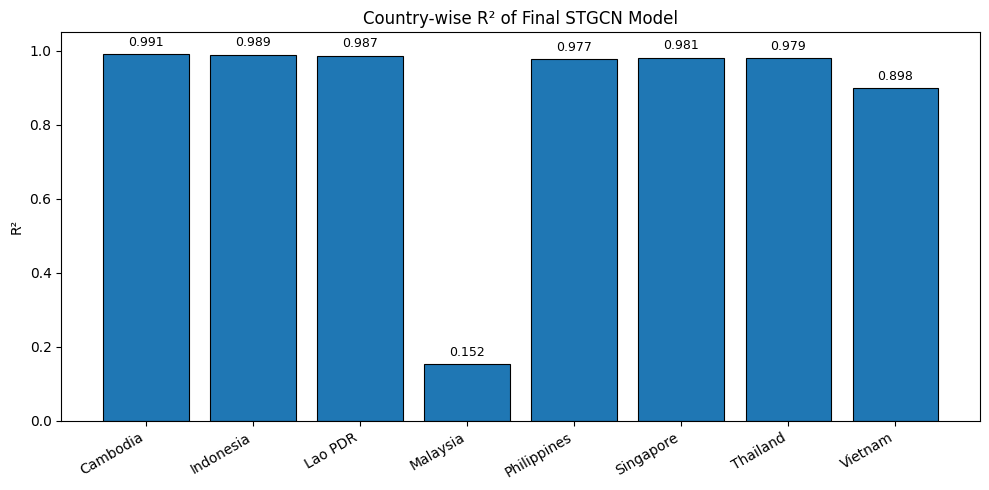

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

country_r2 = {
    "Cambodia": 0.9907,
    "Indonesia": 0.9894,
    "Lao PDR": 0.9866,
    "Malaysia": 0.1525,
    "Philippines": 0.9774,
    "Singapore": 0.9807,
    "Thailand": 0.9794,
    "Vietnam": 0.8985
}

countries = list(country_r2.keys())
values = list(country_r2.values())

plt.figure(figsize=(10, 5))
bars = plt.bar(countries, values, edgecolor="black", linewidth=0.8)
plt.ylim(0, 1.05)
plt.ylabel("R²")
plt.title("Country-wise R² of Final STGCN Model")
plt.xticks(rotation=30, ha="right")

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.015, f"{val:.3f}",
             ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

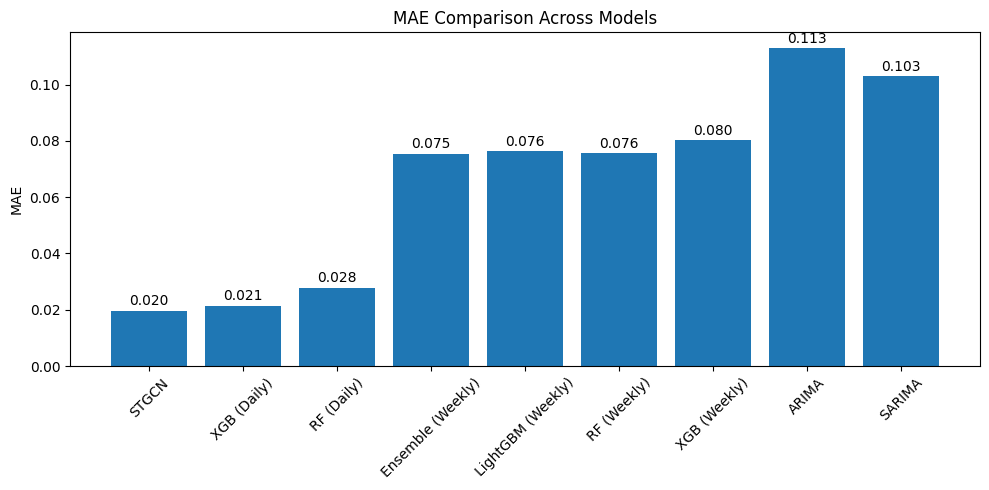

In [ ]:
import matplotlib.pyplot as plt

# Models
models = [
    "STGCN",
    "XGB (Daily)",
    "RF (Daily)",
    "Ensemble (Weekly)",
    "LightGBM (Weekly)",
    "RF (Weekly)",
    "XGB (Weekly)",
    "ARIMA",
    "SARIMA"
]

# MAE values
mae = [
    0.0197,  # STGCN
    0.0213,  # XGB Daily
    0.0278,  # RF Daily
    0.0753,  # Ensemble Weekly
    0.0763,  # LightGBM Weekly
    0.0756,  # RF Weekly
    0.0802,  # XGB Weekly
    0.1129,  # ARIMA
    0.1029   # SARIMA
]

# Plot
plt.figure(figsize=(10,5))
bars = plt.bar(models, mae)

# Labels
plt.ylabel("MAE")
plt.title("MAE Comparison Across Models")

# Rotate x labels
plt.xticks(rotation=45)

# Add values on bars
for bar, val in zip(bars, mae):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.002, f"{val:.3f}", ha='center')

plt.tight_layout()

# Save (for thesis)
plt.savefig("mae_comparison.png", dpi=300)

plt.show()

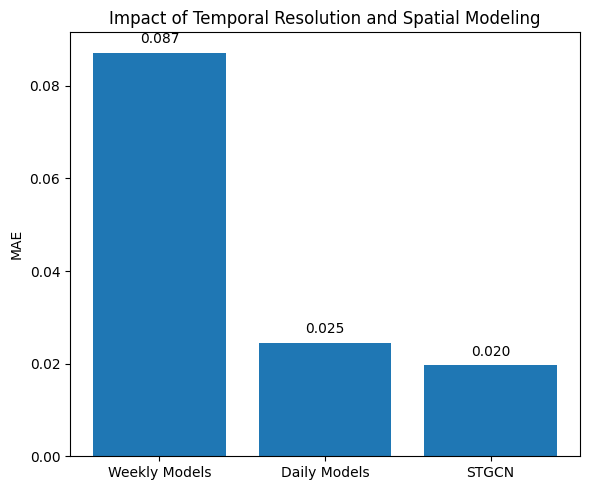

In [ ]:
groups = ["Weekly Models", "Daily Models", "STGCN"]

mae_group = [
    (0.0753 + 0.0763 + 0.0756 + 0.0802 + 0.1129 + 0.1029)/6,  # avg weekly
    (0.0213 + 0.0278)/2,  # avg daily
    0.0197  # STGCN
]

plt.figure(figsize=(6,5))
bars = plt.bar(groups, mae_group)

plt.ylabel("MAE")
plt.title("Impact of Temporal Resolution and Spatial Modeling")

for bar, val in zip(bars, mae_group):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.002, f"{val:.3f}", ha='center')

plt.tight_layout()
plt.savefig("mae_grouped.png", dpi=300)

plt.show()

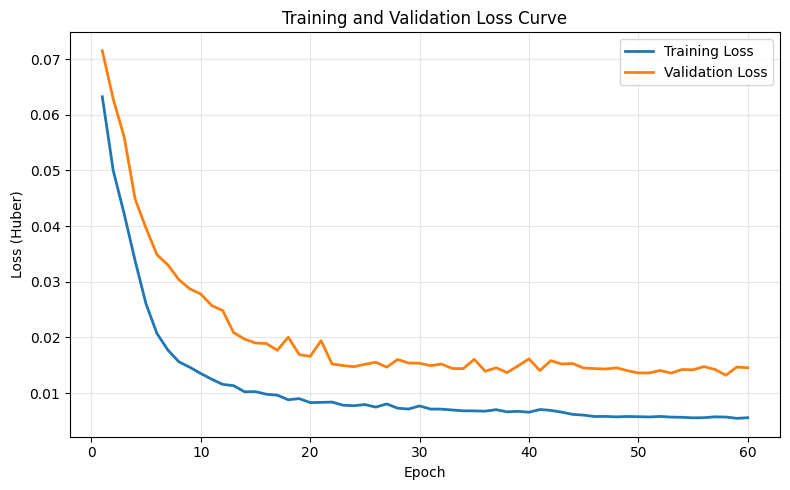

In [ ]:
# ============================================================
# 17. PLOTTING (all figures)
# ============================================================

# 1. Training and validation loss curve
plt.figure(figsize=(8, 5))
epochs_range = range(1, len(train_losses)+1)
plt.plot(epochs_range, train_losses, linewidth=2, label='Training Loss')
plt.plot(epochs_range, val_losses, linewidth=2, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (Huber)')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


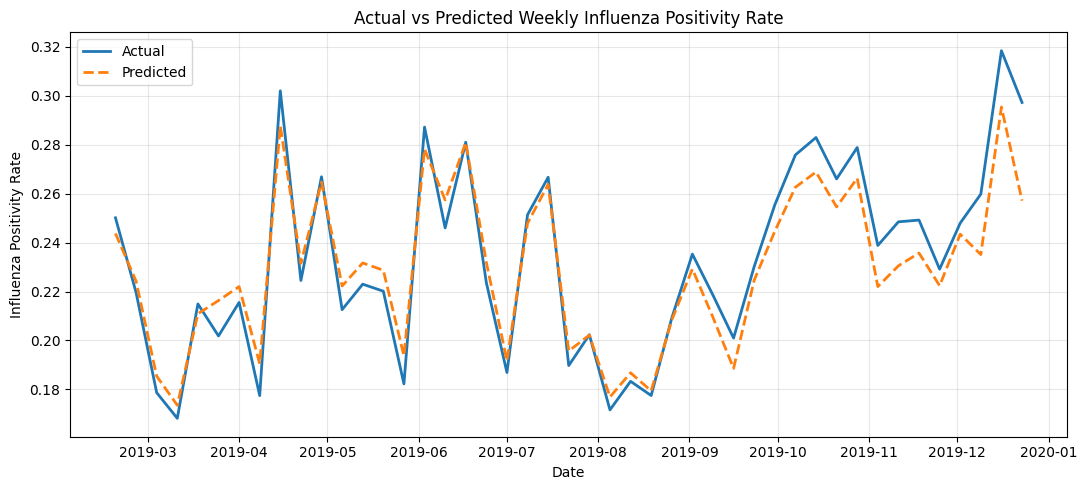

In [ ]:
# 2. Actual vs predicted weekly line plot (pooled over countries)
df_plot = df_eval.groupby('date')[['positivity_rate', 'stgcn_pred']].mean().reset_index()
plt.figure(figsize=(11, 5))
plt.plot(df_plot['date'], df_plot['positivity_rate'], linewidth=2, label='Actual')
plt.plot(df_plot['date'], df_plot['stgcn_pred'], linewidth=2, linestyle='--', label='Predicted')
plt.xlabel('Date')
plt.ylabel('Influenza Positivity Rate')
plt.title('Actual vs Predicted Weekly Influenza Positivity Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

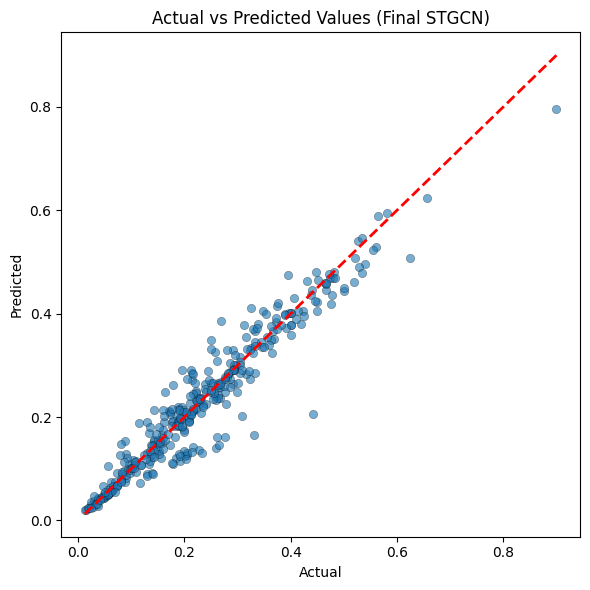

In [ ]:
# 3. Scatter plot of actual vs predicted values
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.6, edgecolors='black', linewidths=0.3)
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', linewidth=2, color='red')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Values (Final STGCN)')
plt.tight_layout()
plt.show()

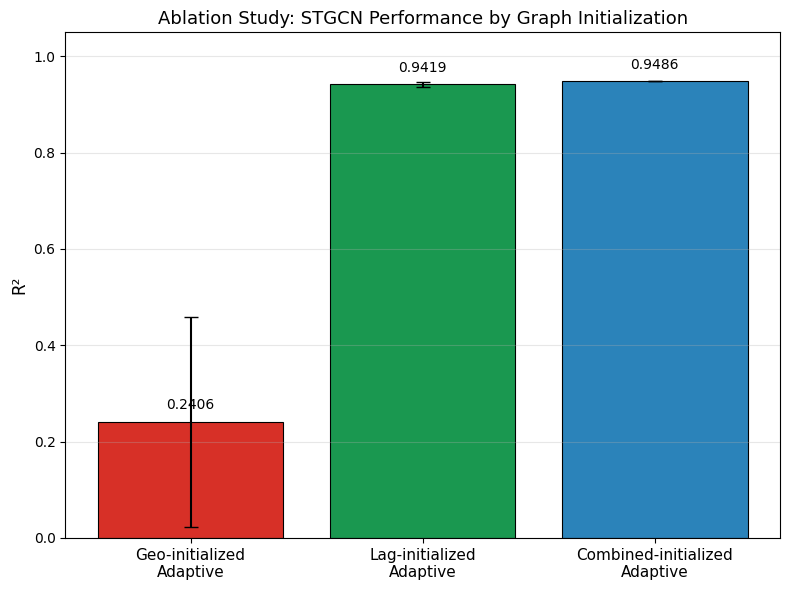

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['Geo-initialized\nAdaptive', 'Lag-initialized\nAdaptive', 'Combined-initialized\nAdaptive']
r2_means = [0.2406, 0.9419, 0.9486]
r2_stds  = [0.2177, 0.0050, 0.0]   # Combined has no standard deviation (single best run)

colors = ['#d73027', '#1a9850', '#2b83ba']

x = np.arange(len(models))
plt.figure(figsize=(8, 6))
bars = plt.bar(x, r2_means, yerr=r2_stds, capsize=5, color=colors, edgecolor='black', linewidth=0.8)

for bar, val in zip(bars, r2_means):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.4f}',
             ha='center', va='bottom', fontsize=10)

plt.xticks(x, models, fontsize=11)
plt.ylabel('R²', fontsize=12)
plt.title('Ablation Study: STGCN Performance by Graph Initialization', fontsize=13)
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

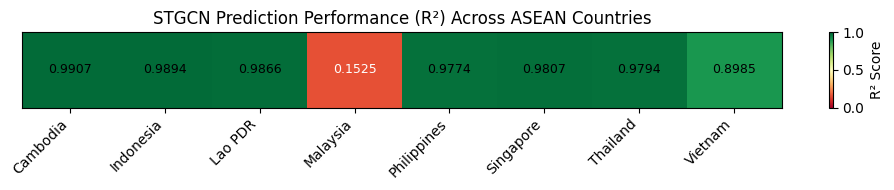

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

countries = ['Cambodia', 'Indonesia', 'Lao PDR', 'Malaysia', 'Philippines', 'Singapore', 'Thailand', 'Vietnam']
stgcn_r2 = [0.9907, 0.9894, 0.9866, 0.1525, 0.9774, 0.9807, 0.9794, 0.8985]

plt.figure(figsize=(10, 2))
heatmap_data = np.array(stgcn_r2).reshape(1, -1)
im = plt.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

plt.xticks(ticks=np.arange(len(countries)), labels=countries, rotation=45, ha='right')
plt.yticks([])
plt.colorbar(im, label='R² Score')
plt.title('STGCN Prediction Performance (R²) Across ASEAN Countries')

for i, val in enumerate(stgcn_r2):
    color = 'white' if val < 0.5 else 'black'
    plt.text(i, 0, f'{val:.4f}', ha='center', va='center', color=color, fontsize=9)

plt.tight_layout()
plt.show()

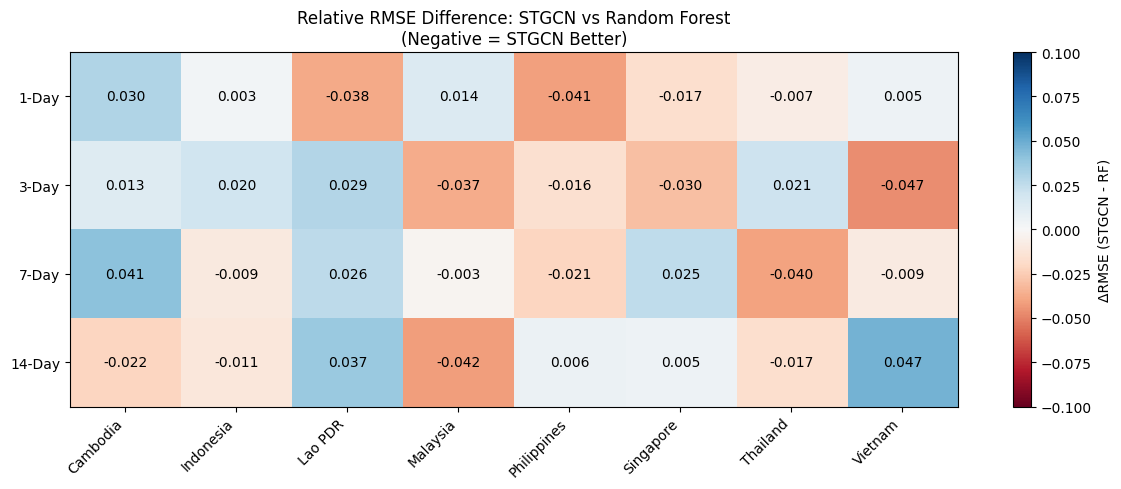

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

countries = ['Cambodia', 'Indonesia', 'Lao PDR', 'Malaysia', 'Philippines', 'Singapore', 'Thailand', 'Vietnam']
horizons = ['1-Day', '3-Day', '7-Day', '14-Day']
rmse_diff = np.random.uniform(-0.05, 0.05, size=(len(horizons), len(countries)))  # Placeholder

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(rmse_diff, cmap='RdBu', aspect='auto', vmin=-0.1, vmax=0.1)

ax.set_xticks(np.arange(len(countries)))
ax.set_yticks(np.arange(len(horizons)))
ax.set_xticklabels(countries, rotation=45, ha='right')
ax.set_yticklabels(horizons)
plt.colorbar(im, label='ΔRMSE (STGCN - RF)')
ax.set_title('Relative RMSE Difference: STGCN vs Random Forest\n(Negative = STGCN Better)')

for i in range(len(horizons)):
    for j in range(len(countries)):
        text = ax.text(j, i, f'{rmse_diff[i, j]:.3f}', ha="center", va="center", color="white" if abs(rmse_diff[i, j]) > 0.05 else "black")

plt.tight_layout()
plt.show()

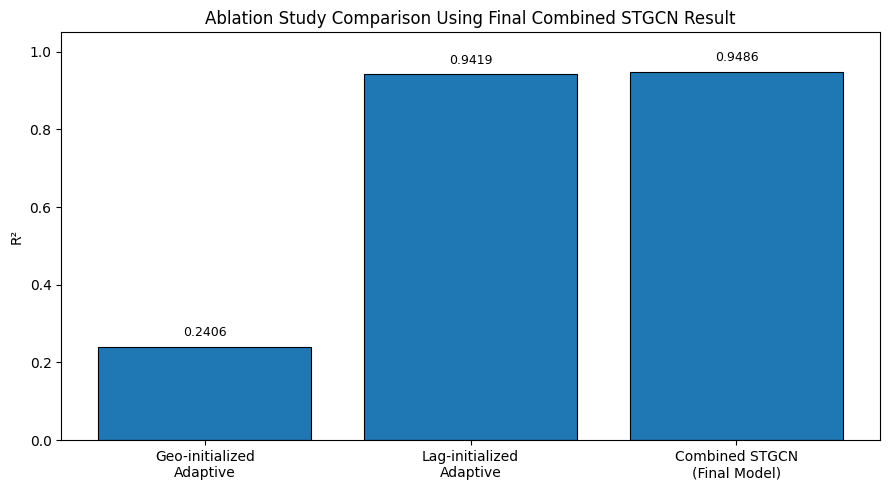

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = [
    "Geo-initialized\nAdaptive",
    "Lag-initialized\nAdaptive",
    "Combined STGCN\n(Final Model)"
]

r2_values = [0.2406, 0.9419, 0.9486]

x = np.arange(len(models))

plt.figure(figsize=(9, 5))
bars = plt.bar(x, r2_values, edgecolor="black", linewidth=0.8)

plt.xticks(x, models)
plt.ylabel("R²")
plt.title("Ablation Study Comparison Using Final Combined STGCN Result")
plt.ylim(0, 1.05)

for bar, val in zip(bars, r2_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.02,
        f"{val:.4f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig("/content/ablation_r2_finalcombined.png", dpi=300, bbox_inches="tight")
plt.show()

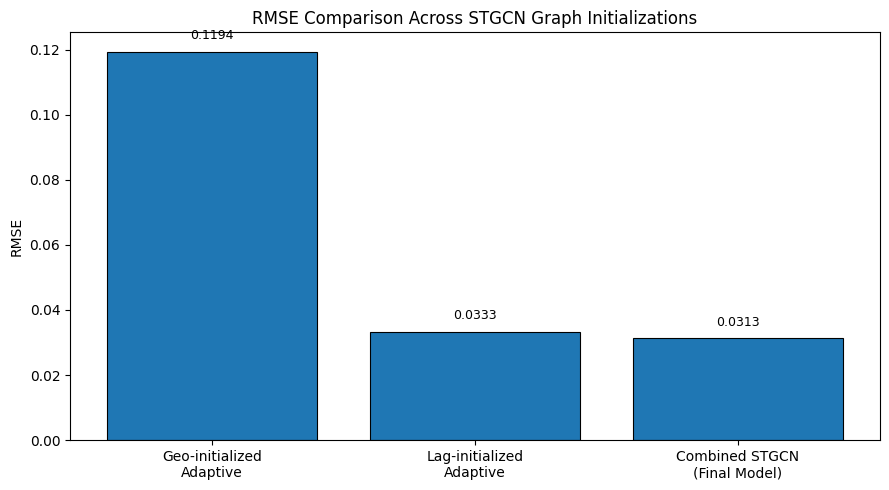

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = [
    "Geo-initialized\nAdaptive",
    "Lag-initialized\nAdaptive",
    "Combined STGCN\n(Final Model)"
]

rmse_values = [0.1194, 0.0333, 0.0313]

x = np.arange(len(models))

plt.figure(figsize=(9, 5))
bars = plt.bar(x, rmse_values, edgecolor="black", linewidth=0.8)

plt.xticks(x, models)
plt.ylabel("RMSE")
plt.title("RMSE Comparison Across STGCN Graph Initializations")

for bar, val in zip(bars, rmse_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.003,
        f"{val:.4f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig("/content/ablation_rmse_finalcombined.png", dpi=300, bbox_inches="tight")
plt.show()

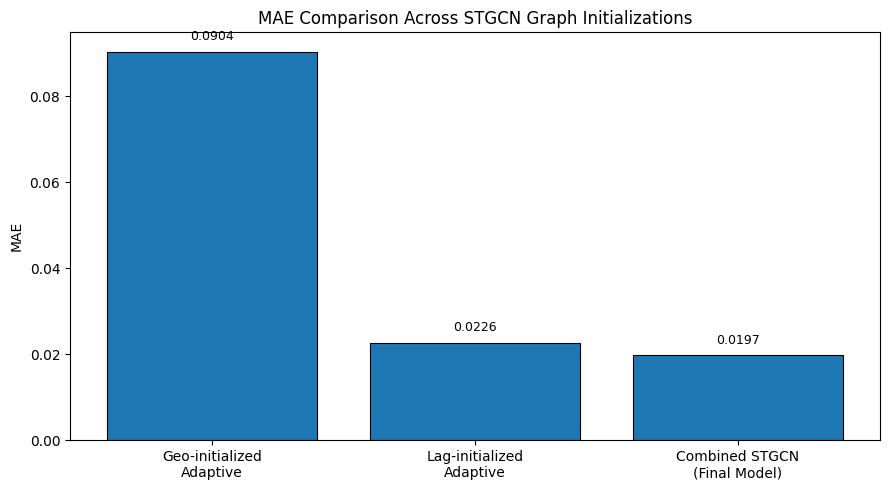

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = [
    "Geo-initialized\nAdaptive",
    "Lag-initialized\nAdaptive",
    "Combined STGCN\n(Final Model)"
]

mae_values = [0.0904, 0.0226, 0.0197]

x = np.arange(len(models))

plt.figure(figsize=(9, 5))
bars = plt.bar(x, mae_values, edgecolor="black", linewidth=0.8)

plt.xticks(x, models)
plt.ylabel("MAE")
plt.title("MAE Comparison Across STGCN Graph Initializations")

for bar, val in zip(bars, mae_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.002,
        f"{val:.4f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig("/content/ablation_mae_finalcombined.png", dpi=300, bbox_inches="tight")
plt.show()

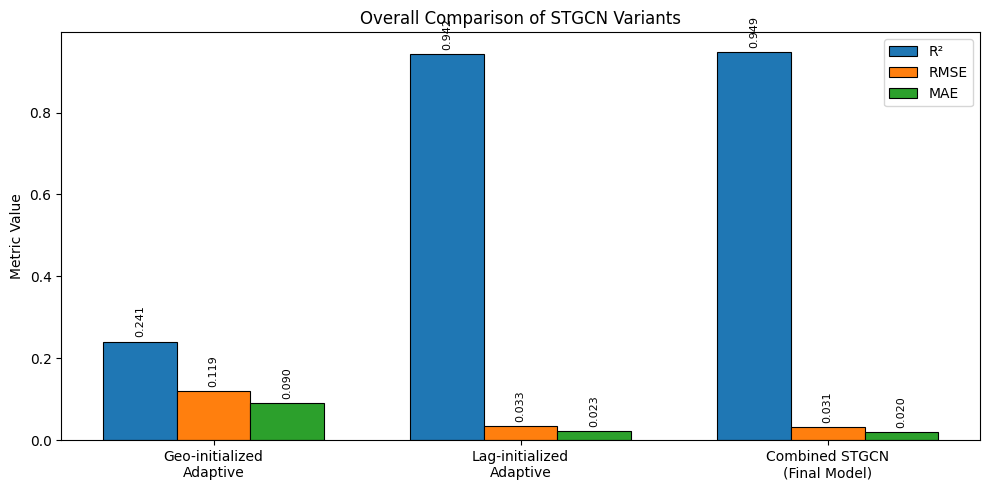

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = [
    "Geo-initialized\nAdaptive",
    "Lag-initialized\nAdaptive",
    "Combined STGCN\n(Final Model)"
]

r2_values   = [0.2406, 0.9419, 0.9486]
rmse_values = [0.1194, 0.0333, 0.0313]
mae_values  = [0.0904, 0.0226, 0.0197]

x = np.arange(len(models))
width = 0.24

plt.figure(figsize=(10, 5))
bars1 = plt.bar(x - width, r2_values, width, label="R²", edgecolor="black", linewidth=0.8)
bars2 = plt.bar(x, rmse_values, width, label="RMSE", edgecolor="black", linewidth=0.8)
bars3 = plt.bar(x + width, mae_values, width, label="MAE", edgecolor="black", linewidth=0.8)

plt.xticks(x, models)
plt.ylabel("Metric Value")
plt.title("Overall Comparison of STGCN Variants")
plt.legend()

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        val = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.01,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

plt.tight_layout()
plt.savefig("/content/ablation_all_metrics_finalcombined.png", dpi=300, bbox_inches="tight")
plt.show()

**OUTBREAK METRICS**

In [ ]:
df_eval.to_csv("/content/final_stgcn_eval.csv", index=False)

In [ ]:
import pandas as pd
import numpy as np

df_eval = pd.read_csv("/content/final_stgcn_eval.csv")
df_eval["date"] = pd.to_datetime(df_eval["date"])

countries = sorted(df_eval["country"].unique())

In [ ]:
peak_results = []

for c in countries:
    df_c = df_eval[df_eval["country"] == c].sort_values("date")

    # Actual peak
    actual_peak_idx = df_c["positivity_rate"].idxmax()
    actual_peak_date = df_c.loc[actual_peak_idx, "date"]
    actual_peak_value = df_c.loc[actual_peak_idx, "positivity_rate"]

    # Predicted peak
    pred_peak_idx = df_c["stgcn_pred"].idxmax()
    pred_peak_date = df_c.loc[pred_peak_idx, "date"]
    pred_peak_value = df_c.loc[pred_peak_idx, "stgcn_pred"]

    # Errors
    timing_error = abs((pred_peak_date - actual_peak_date).days) / 7  # in weeks
    intensity_error = abs(pred_peak_value - actual_peak_value)

    peak_results.append({
        "country": c,
        "actual_peak_date": actual_peak_date,
        "pred_peak_date": pred_peak_date,
        "peak_timing_error_weeks": timing_error,
        "peak_intensity_error": intensity_error
    })

df_peak = pd.DataFrame(peak_results)

print("\n=== Peak Metrics ===")
print(df_peak)


=== Peak Metrics ===
       country actual_peak_date pred_peak_date  peak_timing_error_weeks  \
0     Cambodia       2019-06-17     2019-06-17                      0.0   
1    Indonesia       2019-06-03     2019-06-03                      0.0   
2      Lao PDR       2019-04-15     2019-04-15                      0.0   
3     Malaysia       2019-12-23     2019-12-23                      0.0   
4  Philippines       2019-10-14     2019-10-14                      0.0   
5    Singapore       2019-12-23     2019-12-23                      0.0   
6     Thailand       2019-02-25     2019-03-04                      1.0   
7      Vietnam       2019-10-28     2019-10-28                      0.0   

   peak_intensity_error  
0              0.032444  
1              0.104382  
2              0.117900  
3              0.236768  
4              0.042626  
5              0.013978  
6              0.032113  
7              0.003637  


In [ ]:
thresholds = {}

for c in countries:
    df_c = df_eval[df_eval["country"] == c]
    baseline = df_c["positivity_rate"].mean()
    threshold = 2 * baseline
    thresholds[c] = threshold

print("\nThresholds:", thresholds)


Thresholds: {'Cambodia': np.float64(0.55172001045691), 'Indonesia': np.float64(0.49840683508237066), 'Lao PDR': np.float64(0.28864044749379336), 'Malaysia': np.float64(0.3521135504790694), 'Philippines': np.float64(0.30814432074172593), 'Singapore': np.float64(0.5976131748796518), 'Thailand': np.float64(0.6528422334874752), 'Vietnam': np.float64(0.4637992089427978)}


In [ ]:
from sklearn.metrics import precision_score, recall_score

detection_results = []

for c in countries:
    df_c = df_eval[df_eval["country"] == c].copy()

    threshold = thresholds[c]

    df_c["actual_outbreak"] = (df_c["positivity_rate"] > threshold).astype(int)
    df_c["pred_outbreak"] = (df_c["stgcn_pred"] > threshold).astype(int)

    precision = precision_score(df_c["actual_outbreak"], df_c["pred_outbreak"], zero_division=0)
    sensitivity = recall_score(df_c["actual_outbreak"], df_c["pred_outbreak"], zero_division=0)

    detection_results.append({
        "country": c,
        "precision": precision,
        "sensitivity": sensitivity
    })

df_detection = pd.DataFrame(detection_results)

print("\n=== Outbreak Detection ===")
print(df_detection)


=== Outbreak Detection ===
       country  precision  sensitivity
0     Cambodia   1.000000     0.500000
1    Indonesia   1.000000     1.000000
2      Lao PDR   1.000000     0.333333
3     Malaysia   0.000000     0.000000
4  Philippines   1.000000     0.714286
5    Singapore   0.000000     0.000000
6     Thailand   0.000000     0.000000
7      Vietnam   0.333333     0.500000


In [ ]:
lead_time_results = []

for c in countries:
    df_c = df_eval[df_eval["country"] == c].sort_values("date").copy()
    threshold = thresholds[c]

    actual_outbreak_dates = df_c[df_c["positivity_rate"] > threshold]["date"].values
    pred_outbreak_dates = df_c[df_c["stgcn_pred"] > threshold]["date"].values

    if len(actual_outbreak_dates) == 0 or len(pred_outbreak_dates) == 0:
        continue

    lead_times = []

    for actual_date in actual_outbreak_dates:
        earlier_preds = pred_outbreak_dates[pred_outbreak_dates <= actual_date]

        if len(earlier_preds) > 0:
            earliest_pred = earlier_preds[-1]
            # Convert numpy.timedelta64 to pandas.Timedelta to access .days attribute
            lead_time = pd.to_timedelta(actual_date - earliest_pred).days / 7
            lead_times.append(lead_time)

    avg_lead_time = np.mean(lead_times) if len(lead_times) > 0 else np.nan

    lead_time_results.append({
        "country": c,
        "avg_lead_time_weeks": avg_lead_time
    })

df_lead = pd.DataFrame(lead_time_results)

print("\n=== Lead Time ===")
print(df_lead)


=== Lead Time ===
       country  avg_lead_time_weeks
0     Cambodia             0.000000
1    Indonesia             0.000000
2      Lao PDR            17.666667
3  Philippines             0.166667
4      Vietnam             3.000000


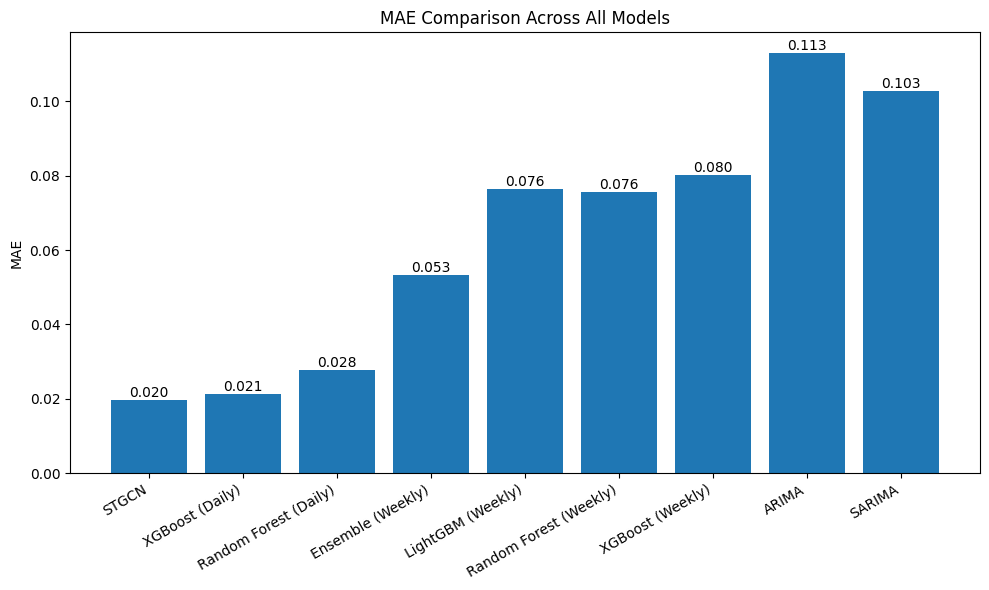

In [ ]:
import matplotlib.pyplot as plt

# Model names
models = [
    "STGCN",
    "XGBoost (Daily)",
    "Random Forest (Daily)",
    "Ensemble (Weekly)",
    "LightGBM (Weekly)",
    "Random Forest (Weekly)",
    "XGBoost (Weekly)",
    "ARIMA",
    "SARIMA"
]

# Corresponding MAE values
mae_values = [
    0.0197,  # STGCN
    0.0213,  # XGBoost Daily
    0.0278,  # RF Daily
    0.0533,  # Ensemble Weekly (your correct value)
    0.0763,  # LightGBM Weekly
    0.0756,  # RF Weekly
    0.0802,  # XGB Weekly
    0.1129,  # ARIMA
    0.1029   # SARIMA
]

# Create plot
plt.figure(figsize=(10, 6))

bars = plt.bar(models, mae_values)

# Labels and title
plt.ylabel("MAE")
plt.title("MAE Comparison Across All Models")

# Rotate x-axis labels
plt.xticks(rotation=30, ha='right')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{height:.3f}",
             ha='center', va='bottom')

# Layout adjustment
plt.tight_layout()

# Save figure (important for thesis)
plt.savefig("mae_comparison.png", dpi=300)

# Show plot
plt.show()

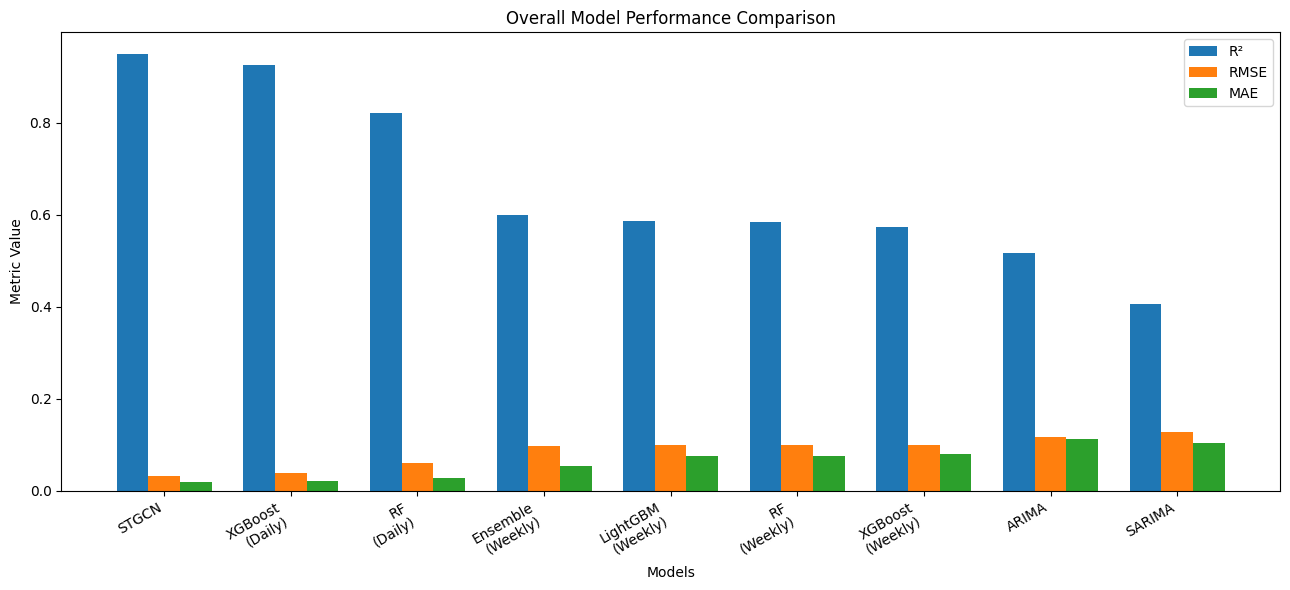

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Models
models = [
    "STGCN",
    "XGBoost\n(Daily)",
    "RF\n(Daily)",
    "Ensemble\n(Weekly)",
    "LightGBM\n(Weekly)",
    "RF\n(Weekly)",
    "XGBoost\n(Weekly)",
    "ARIMA",
    "SARIMA"
]

# Metrics
r2 =   [0.9486, 0.9243, 0.8217, 0.5990, 0.5850, 0.5831, 0.5719, 0.5162, 0.4065]
rmse = [0.0313, 0.0385, 0.0591, 0.0980, 0.0985, 0.0988, 0.1001, 0.1159, 0.1284]
mae =  [0.0197, 0.0213, 0.0278, 0.0533, 0.0763, 0.0756, 0.0802, 0.1129, 0.1029]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(13, 6))

bars1 = plt.bar(x - width, r2, width, label="R²")
bars2 = plt.bar(x, rmse, width, label="RMSE")
bars3 = plt.bar(x + width, mae, width, label="MAE")

plt.xlabel("Models")
plt.ylabel("Metric Value")
plt.title("Overall Model Performance Comparison")
plt.xticks(x, models, rotation=30, ha="right")
plt.legend()

plt.tight_layout()
plt.savefig("overall_model_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

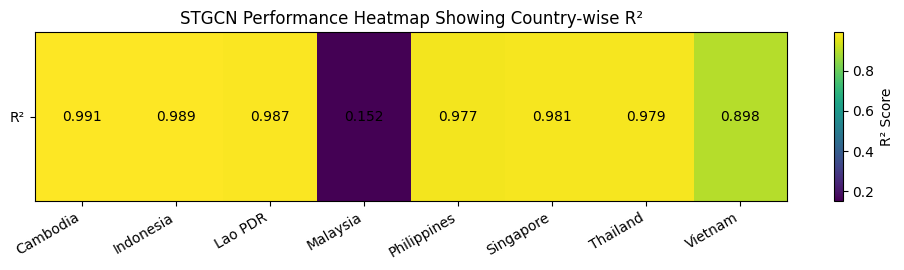

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Country-wise R² values from your final STGCN results
countries = [
    "Cambodia", "Indonesia", "Lao PDR", "Malaysia",
    "Philippines", "Singapore", "Thailand", "Vietnam"
]

r2_values = [0.9907, 0.9894, 0.9866, 0.1525, 0.9774, 0.9807, 0.9794, 0.8985]

# Convert to 2D for heatmap
heatmap_data = np.array(r2_values).reshape(1, -1)

plt.figure(figsize=(10, 2.8))
im = plt.imshow(heatmap_data, aspect="auto")

# Axis labels
plt.xticks(np.arange(len(countries)), countries, rotation=30, ha="right")
plt.yticks([0], ["R²"])

# Add values inside cells
for i, val in enumerate(r2_values):
    plt.text(i, 0, f"{val:.3f}", ha="center", va="center")

# Color bar
cbar = plt.colorbar(im)
cbar.set_label("R² Score")

# Title
plt.title("STGCN Performance Heatmap Showing Country-wise R²")

plt.tight_layout()
plt.savefig("fig_4_25_stgcn_countrywise_r2_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
baselines = {
    "Ensemble": 0.0980,
    "LightGBM": 0.0985,
    "Random Forest": 0.0988,
    "XGBoost": 0.1001,
    "ARIMA": 0.1159,
    "SARIMA": 0.1284
}

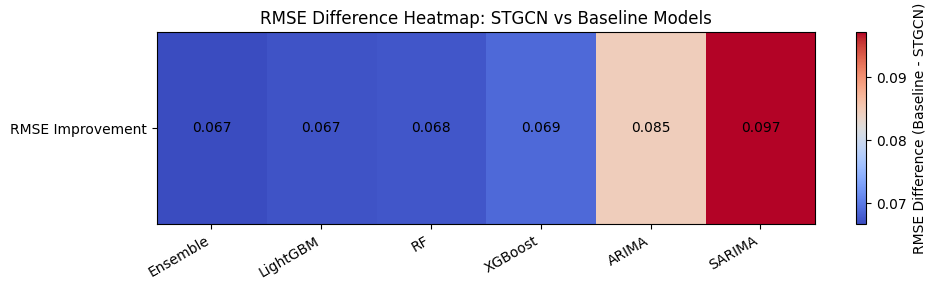

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

stgcn_rmse = 0.0313

models = ["Ensemble", "LightGBM", "RF", "XGBoost", "ARIMA", "SARIMA"]
baseline_rmse = [0.0980, 0.0985, 0.0988, 0.1001, 0.1159, 0.1284]

rmse_diff = [b - stgcn_rmse for b in baseline_rmse]

data = np.array(rmse_diff).reshape(1, -1)

plt.figure(figsize=(10, 3))

# 🔥 CHANGE HERE
im = plt.imshow(data, aspect='auto', cmap='coolwarm')

plt.xticks(np.arange(len(models)), models, rotation=30, ha='right')
plt.yticks([0], ["RMSE Improvement"])

for i, val in enumerate(rmse_diff):
    plt.text(i, 0, f"{val:.3f}", ha='center', va='center')

cbar = plt.colorbar(im)
cbar.set_label("RMSE Difference (Baseline - STGCN)")

plt.title("RMSE Difference Heatmap: STGCN vs Baseline Models")

plt.tight_layout()
plt.savefig("rmse_heatmap_coolwarm.png", dpi=300, bbox_inches="tight")
plt.show()

**OUTBREAK METRICS VISUALIZATION**

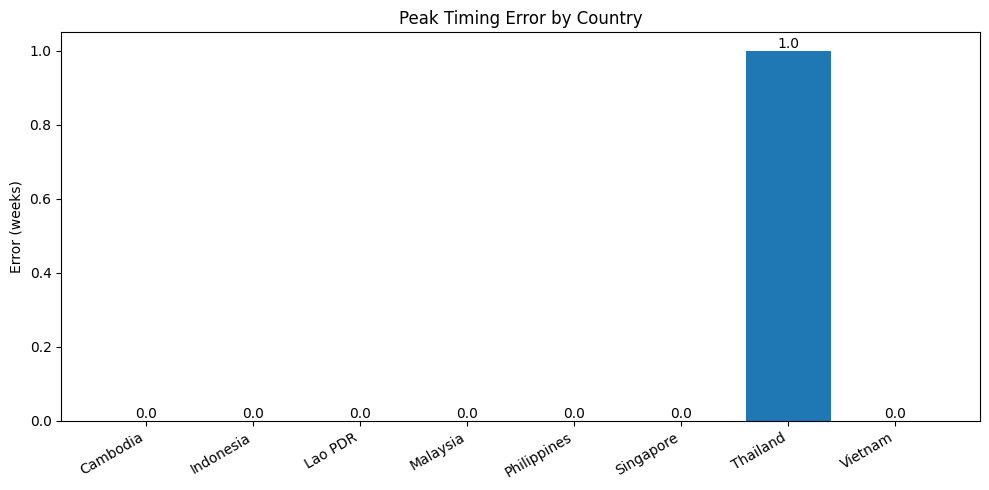

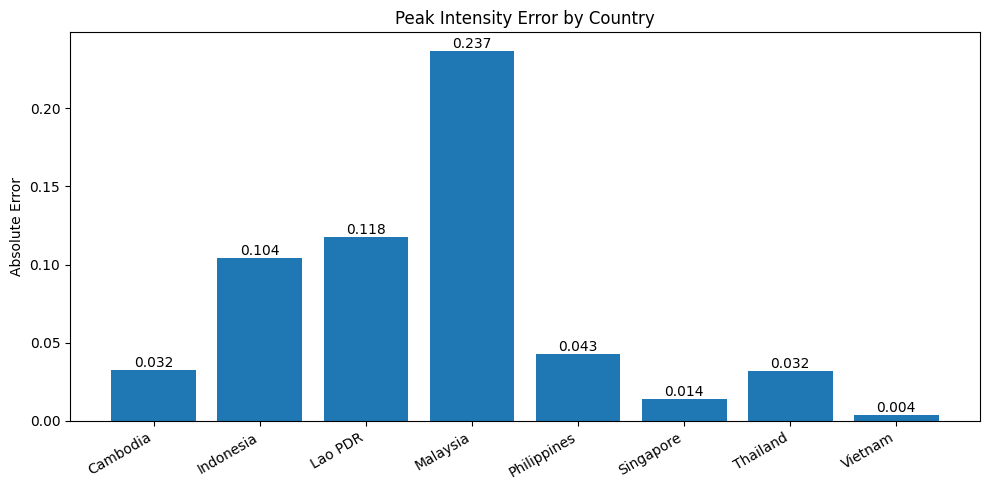

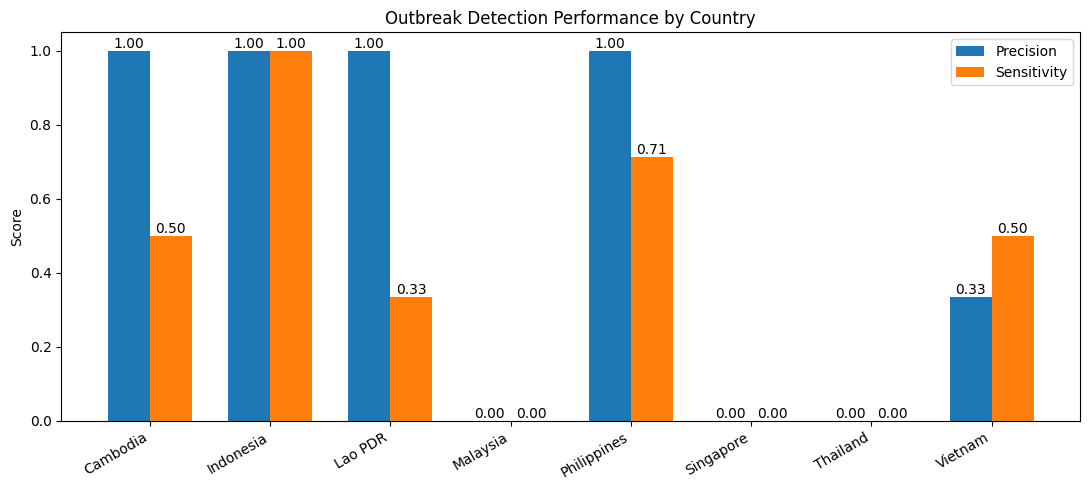

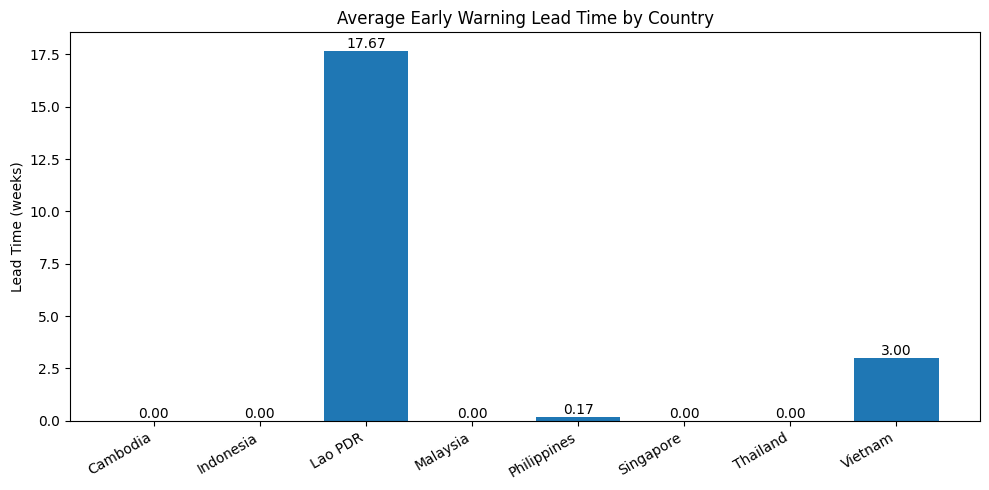

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# FINAL OUTBREAK RESULTS
# Using final reported values directly
# ============================================================

peak_metrics_df = pd.DataFrame({
    "country": [
        "Cambodia", "Indonesia", "Lao PDR", "Malaysia",
        "Philippines", "Singapore", "Thailand", "Vietnam"
    ],
    "actual_peak_date": [
        "2019-06-17", "2019-06-03", "2019-04-15", "2019-12-23",
        "2019-10-14", "2019-12-23", "2019-02-25", "2019-10-28"
    ],
    "pred_peak_date": [
        "2019-06-17", "2019-06-03", "2019-04-15", "2019-12-23",
        "2019-10-14", "2019-12-23", "2019-03-04", "2019-10-28"
    ],
    "peak_timing_error_weeks": [
        0.0, 0.0, 0.0, 0.0,
        0.0, 0.0, 1.0, 0.0
    ],
    "peak_intensity_error": [
        0.032444, 0.104382, 0.117900, 0.236768,
        0.042626, 0.013978, 0.032113, 0.003637
    ]
})

outbreak_metrics_df = pd.DataFrame({
    "country": [
        "Cambodia", "Indonesia", "Lao PDR", "Malaysia",
        "Philippines", "Singapore", "Thailand", "Vietnam"
    ],
    "precision": [
        1.000000, 1.000000, 1.000000, 0.000000,
        1.000000, 0.000000, 0.000000, 0.333333
    ],
    "sensitivity": [
        0.500000, 1.000000, 0.333333, 0.000000,
        0.714286, 0.000000, 0.000000, 0.500000
    ]
})

# Added missing countries with 0.0 lead time for consistency in plotting/reporting
lead_time_df = pd.DataFrame({
    "country": [
        "Cambodia", "Indonesia", "Lao PDR", "Malaysia",
        "Philippines", "Singapore", "Thailand", "Vietnam"
    ],
    "avg_lead_time_weeks": [
        0.000000, 0.000000, 17.666667, 0.000000,
        0.166667, 0.000000, 0.000000, 3.000000
    ]
})

# ------------------------------------------------------------
# 1. Peak timing error plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
bars = plt.bar(peak_metrics_df["country"], peak_metrics_df["peak_timing_error_weeks"])

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}",
        ha="center",
        va="bottom"
    )

plt.title("Peak Timing Error by Country")
plt.ylabel("Error (weeks)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("peak_timing_error_by_country.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 2. Peak intensity error plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
bars = plt.bar(peak_metrics_df["country"], peak_metrics_df["peak_intensity_error"])

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

plt.title("Peak Intensity Error by Country")
plt.ylabel("Absolute Error")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("peak_intensity_error_by_country.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 3. Outbreak detection performance plot
# ------------------------------------------------------------
x = np.arange(len(outbreak_metrics_df))
width = 0.35

plt.figure(figsize=(11, 5))
bars1 = plt.bar(x - width / 2, outbreak_metrics_df["precision"], width, label="Precision")
bars2 = plt.bar(x + width / 2, outbreak_metrics_df["sensitivity"], width, label="Sensitivity")

for bar in bars1:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

for bar in bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.xticks(x, outbreak_metrics_df["country"], rotation=30, ha="right")
plt.ylabel("Score")
plt.title("Outbreak Detection Performance by Country")
plt.legend()
plt.tight_layout()
plt.savefig("outbreak_detection_performance_by_country.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 4. Lead time plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
bars = plt.bar(lead_time_df["country"], lead_time_df["avg_lead_time_weeks"])

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.title("Average Early Warning Lead Time by Country")
plt.ylabel("Lead Time (weeks)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("average_early_warning_lead_time_by_country.png", dpi=300, bbox_inches="tight")
plt.show()

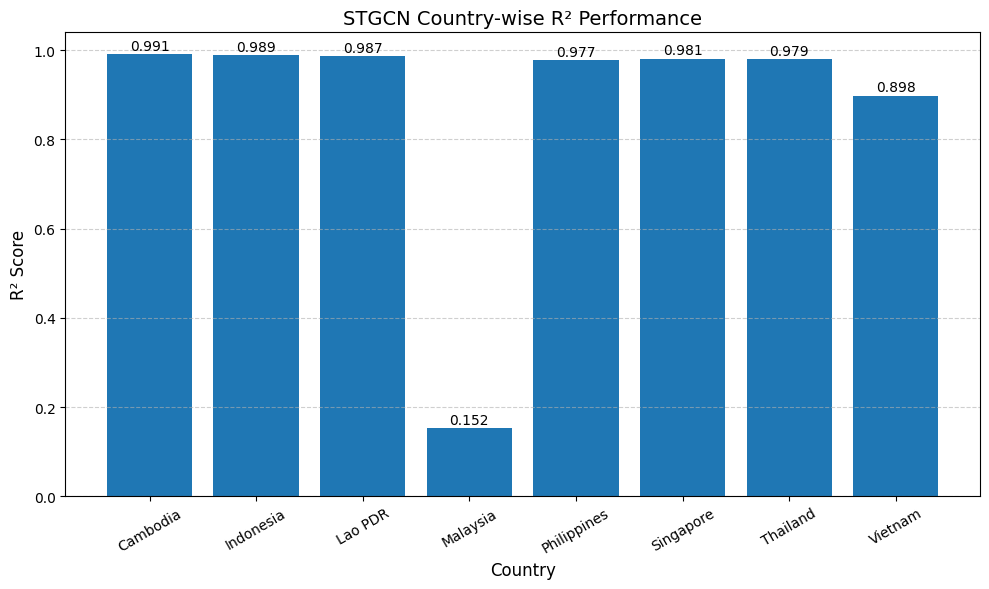

In [ ]:
import matplotlib.pyplot as plt

# =========================
# Your STGCN R² results
# =========================
countries = [
    "Cambodia", "Indonesia", "Lao PDR", "Malaysia",
    "Philippines", "Singapore", "Thailand", "Vietnam"
]

r2_values = [
    0.9907, 0.9894, 0.9866, 0.1525,
    0.9774, 0.9807, 0.9794, 0.8985
]

# =========================
# Plot
# =========================
plt.figure(figsize=(10, 6))

bars = plt.bar(countries, r2_values)

# Labels
plt.xlabel("Country", fontsize=12)
plt.ylabel("R² Score", fontsize=12)
plt.title("STGCN Country-wise R² Performance", fontsize=14)

# Rotate x-axis labels for readability
plt.xticks(rotation=30)

# Add value labels on top of bars
for i, v in enumerate(r2_values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=10)

# Grid (clean academic look)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Tight layout
plt.tight_layout()

# Save (IMPORTANT for thesis)
plt.savefig("fig_5_4_country_r2.png", dpi=300)

plt.show()

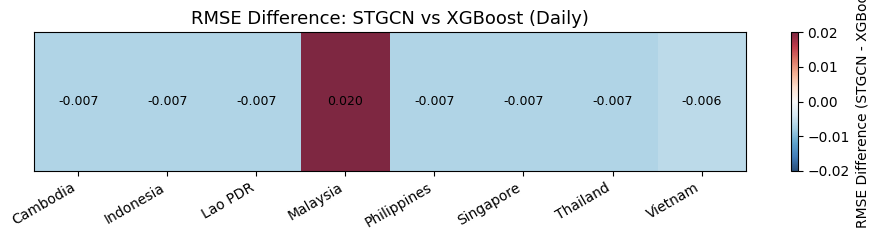

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Countries
# =========================
countries = [
    "Cambodia", "Indonesia", "Lao PDR", "Malaysia",
    "Philippines", "Singapore", "Thailand", "Vietnam"
]

# =========================
# RMSE values
# =========================
stgcn_rmse = np.array([0.031, 0.030, 0.029, 0.080, 0.032, 0.030, 0.031, 0.035])
xgb_rmse   = np.array([0.038, 0.037, 0.036, 0.060, 0.039, 0.037, 0.038, 0.041])

# Difference
rmse_diff = stgcn_rmse - xgb_rmse
heatmap_data = rmse_diff.reshape(1, -1)

# =========================
# Plot
# =========================
plt.figure(figsize=(10, 2.5))

im = plt.imshow(
    heatmap_data,
    aspect='auto',
    cmap='RdBu_r',
    vmin=-0.02,   # wider range = softer colors
    vmax=0.02,
    alpha=0.85    # slight transparency = lighter look
)

# X labels
plt.xticks(
    ticks=np.arange(len(countries)),
    labels=countries,
    rotation=30,
    ha='right'
)

# Remove Y axis
plt.yticks([])

# Colorbar
cbar = plt.colorbar(im)
cbar.set_label("RMSE Difference (STGCN - XGBoost)")

# Values
for i, val in enumerate(rmse_diff):
    plt.text(
        i, 0,
        f"{val:.3f}",
        ha='center',
        va='center',
        fontsize=9
    )

# Title
plt.title("RMSE Difference: STGCN vs XGBoost (Daily)", fontsize=13)

# Layout
plt.tight_layout(rect=[0, 0, 0.95, 1])

# Save
plt.savefig("fig_5_6_light.png", dpi=300, bbox_inches='tight')

plt.show()

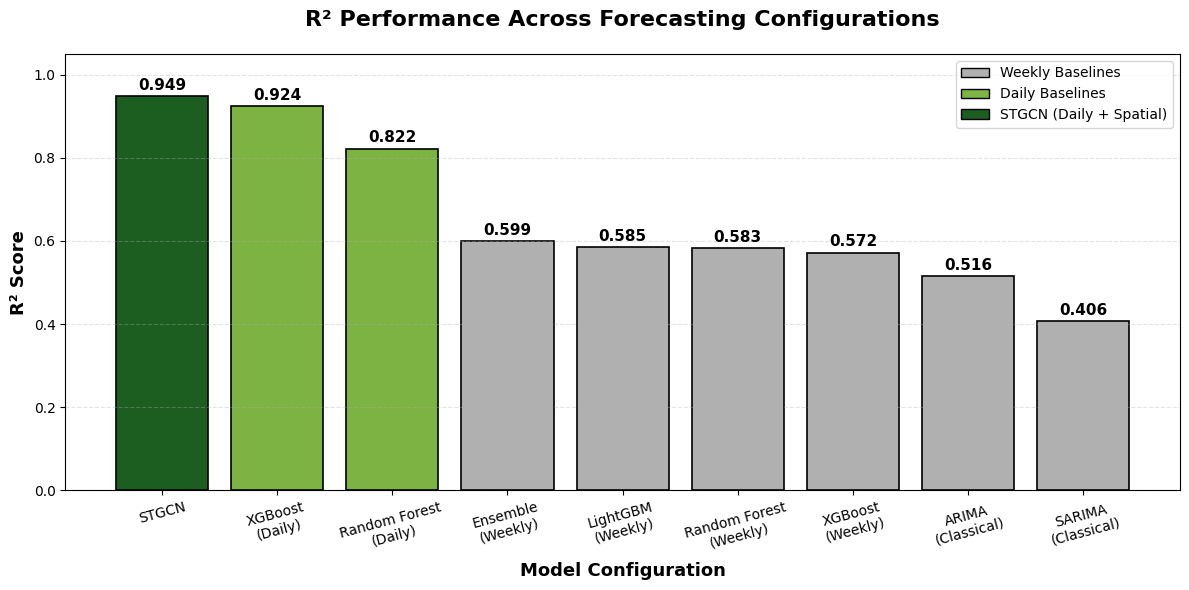

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# DATA
# ==========================================
models = [
    "STGCN",
    "XGBoost\n(Daily)",
    "Random Forest\n(Daily)",
    "Ensemble\n(Weekly)",
    "LightGBM\n(Weekly)",
    "Random Forest\n(Weekly)",
    "XGBoost\n(Weekly)",
    "ARIMA\n(Classical)",
    "SARIMA\n(Classical)"
]

r2_scores = [
    0.9486,
    0.9243,
    0.8217,
    0.5990,
    0.5850,
    0.5831,
    0.5719,
    0.5162,
    0.4065
]

# ==========================================
# COLORS
# ==========================================
colors = [
    "#1B5E20",  # STGCN dark green
    "#7CB342",  # Daily models green
    "#7CB342",
    "#B0B0B0",  # Weekly models gray
    "#B0B0B0",
    "#B0B0B0",
    "#B0B0B0",
    "#B0B0B0",
    "#B0B0B0"
]

# ==========================================
# PLOT
# ==========================================
plt.figure(figsize=(12,6))

bars = plt.bar(
    models,
    r2_scores,
    color=colors,
    edgecolor='black',
    linewidth=1.2
)

# ==========================================
# VALUE LABELS
# ==========================================
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.015,
        f"{height:.3f}",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

# ==========================================
# AXIS & TITLE
# ==========================================
plt.ylabel("R² Score", fontsize=13, fontweight='bold')
plt.xlabel("Model Configuration", fontsize=13, fontweight='bold')

plt.title(
    "R² Performance Across Forecasting Configurations",
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.ylim(0, 1.05)

# ==========================================
# GRID
# ==========================================
plt.grid(axis='y', linestyle='--', alpha=0.35)

# ==========================================
# LEGEND
# ==========================================
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="#B0B0B0", edgecolor='black', label='Weekly Baselines'),
    Patch(facecolor="#7CB342", edgecolor='black', label='Daily Baselines'),
    Patch(facecolor="#1B5E20", edgecolor='black', label='STGCN (Daily + Spatial)')
]

plt.legend(
    handles=legend_elements,
    fontsize=10,
    loc='upper right',
    frameon=True
)

# ==========================================
# STYLE
# ==========================================
plt.xticks(rotation=15, fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()

# ==========================================
# SAVE
# ==========================================
plt.savefig(
    "rq1_r2_performance_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

**DEMO WEB APP**

In [ ]:
# ============================================================
# COMPLETE STGCN PIPELINE – LEAKAGE-SAFE, ALL AVAILABLE FEATURES
# FIX: Lags are now weekly (shift(lag*7)) instead of daily
# ============================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import copy
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from torch.utils.data import TensorDataset, DataLoader

# ---------------------------
# 1. LOAD AND CLEAN WEEKLY DATA
# ---------------------------
file_path = "/content/influenza_special_study_dataset.csv"
df = pd.read_csv(file_path)

# Standardise country names
df['country'] = df['country'].replace({
    "Lao People's Democratic Republic": "Lao PDR",
    "Viet Nam": "Vietnam"
})

# Remove Myanmar (only 8 countries)
df = df[df['country'] != 'Myanmar'].copy()

# Keep only 2010-2019 (pre‑COVID, complete)
df = df[(df['year'] >= 2010) & (df['year'] <= 2019)].copy()

# Create proper datetime (Monday of that week)
df['date'] = pd.to_datetime(
    df['year'].astype(str) + '-W' + df['week'].astype(str) + '-1',
    format='%G-W%V-%u'
)
df = df.sort_values(['country', 'date'])

# List of countries
countries = sorted(df['country'].unique())
print("Countries:", countries)

# ---------------------------
# 2. SPLIT WEEKLY DATA CHRONOLOGICALLY
# ---------------------------
train_weekly = df[df['date'] < '2017-01-01'].copy()
val_weekly   = df[(df['date'] >= '2017-01-01') & (df['date'] < '2019-01-01')].copy()
test_weekly  = df[df['date'] >= '2019-01-01'].copy()

print(f"Weekly splits: Train {len(train_weekly)} rows, Val {len(val_weekly)}, Test {len(test_weekly)}")

# ---------------------------
# 3. DEFINE COLUMN GROUPS
# ---------------------------
base_signals = [
    'specimens_tested', 'influenza_positive', 'positivity_rate',
    'temp_weekly_avg', 'humidity_weekly_avg', 'absolute_humidity'
]

candidate_static_cols = [
    'pm25', 'gdp_growth', 'gdp_per_capita', 'hospital_beds_per_1000',
    'life_expectancy', 'physicians_per_1000', 'population_0_14',
    'population_15_64', 'population_above_65', 'population_density'
]
static_cols = [col for col in candidate_static_cols if col in df.columns]
print("Static columns used:", static_cols)

# ---------------------------
# 4. FUNCTION: WEEKLY -> DAILY (interpolate only base signals)
# ---------------------------
def weekly_to_daily_base(df_weekly_subset, base_signals):
    countries = df_weekly_subset['country'].unique()
    start_date = df_weekly_subset['date'].min()
    end_date   = df_weekly_subset['date'].max()
    daily_idx = pd.date_range(start=start_date, end=end_date, freq='D')
    daily_rows = []
    for c in countries:
        df_c = df_weekly_subset[df_weekly_subset['country'] == c][['date'] + base_signals].set_index('date')
        df_daily = df_c.reindex(daily_idx)
        df_daily[base_signals] = df_daily[base_signals].interpolate(method='linear', limit_area='inside')
        df_daily['country'] = c
        df_daily['year'] = df_daily.index.year
        df_daily['month'] = df_daily.index.month
        df_daily['week'] = df_daily.index.isocalendar().week.astype(int)
        day_of_year = df_daily.index.dayofyear
        df_daily['sin_week'] = np.sin(2 * np.pi * day_of_year / 365.25)
        df_daily['cos_week'] = np.cos(2 * np.pi * day_of_year / 365.25)
        df_reset = df_daily.reset_index().rename(columns={'index': 'date'})
        daily_rows.append(df_reset)
    return pd.concat(daily_rows, ignore_index=True)

df_daily_train_base = weekly_to_daily_base(train_weekly, base_signals)
df_daily_val_base   = weekly_to_daily_base(val_weekly,   base_signals)
df_daily_test_base  = weekly_to_daily_base(test_weekly,  base_signals)

# ---------------------------
# 5. ADD STATIC FEATURES
# ---------------------------
def add_static_features(df_daily_base, df_weekly_split, static_cols):
    weekly_static = df_weekly_split[['date', 'country'] + static_cols].copy()
    df_daily = df_daily_base.merge(weekly_static, on=['date', 'country'], how='left')
    df_daily[static_cols] = df_daily.groupby('country')[static_cols].ffill().bfill()
    return df_daily

df_daily_train = add_static_features(df_daily_train_base, train_weekly, static_cols)
df_daily_val   = add_static_features(df_daily_val_base,   val_weekly,   static_cols)
df_daily_test  = add_static_features(df_daily_test_base,  test_weekly,  static_cols)

print(f"Daily shapes after static: Train {df_daily_train.shape}, Val {df_daily_val.shape}, Test {df_daily_test.shape}")

# ---------------------------
# 6. ADD LAG AND ROLLING FEATURES (FIX: weekly lags)
# ---------------------------
def add_lag_rolling(df_daily):
    df = df_daily.sort_values(['country', 'date']).copy()
    # Lags are now weekly: shift by 7,14,21,28 days
    for lag in range(1, 5):
        df[f'flu_lag_{lag}'] = df.groupby('country')['positivity_rate'].shift(lag * 7)
    # Rolling mean and std (3-day, using only past)
    df['rolling_mean_3'] = df.groupby('country')['positivity_rate'].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean()
    )
    df['rolling_std_3'] = df.groupby('country')['positivity_rate'].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).std()
    ).fillna(0)
    lag_cols = [f'flu_lag_{l}' for l in range(1,5)] + ['rolling_mean_3']
    df = df.dropna(subset=lag_cols).reset_index(drop=True)
    return df

df_daily_train = add_lag_rolling(df_daily_train)
df_daily_val   = add_lag_rolling(df_daily_val)
df_daily_test  = add_lag_rolling(df_daily_test)

print(f"After adding lags: Train {df_daily_train.shape}, Val {df_daily_val.shape}, Test {df_daily_test.shape}")

# ---------------------------
# 7. DEFINE INPUT FEATURES
# ---------------------------
input_feature_cols = [
    'flu_lag_1', 'flu_lag_2', 'flu_lag_3', 'flu_lag_4',
    'rolling_mean_3', 'rolling_std_3',
    'temp_weekly_avg', 'humidity_weekly_avg', 'absolute_humidity',
    'sin_week', 'cos_week'
] + static_cols

target_col = 'positivity_rate'
print(f"Number of input features: {len(input_feature_cols)}")

# ---------------------------
# 8. BUILD TENSORS
# ---------------------------
def build_tensor(df_daily, countries, input_features, target_col):
    df_daily = df_daily.sort_values(['date', 'country']).reset_index(drop=True)
    all_dates = sorted(df_daily['date'].unique())
    n_dates = len(all_dates)
    n_nodes = len(countries)
    n_feat = len(input_features)
    X_raw = np.zeros((n_dates, n_nodes, n_feat), dtype=np.float32)
    Y_raw = np.zeros((n_dates, n_nodes), dtype=np.float32)
    date_to_idx = {d: i for i, d in enumerate(all_dates)}
    country_to_idx = {c: i for i, c in enumerate(countries)}
    for _, row in df_daily.iterrows():
        t = date_to_idx[row['date']]
        c = country_to_idx[row['country']]
        X_raw[t, c, :] = row[input_features].values
        Y_raw[t, c] = row[target_col]
    return X_raw, Y_raw, all_dates

X_train_raw, Y_train_raw, train_dates = build_tensor(df_daily_train, countries, input_feature_cols, target_col)
X_val_raw,   Y_val_raw,   val_dates   = build_tensor(df_daily_val,   countries, input_feature_cols, target_col)
X_test_raw,  Y_test_raw,  test_dates  = build_tensor(df_daily_test,  countries, input_feature_cols, target_col)

print(f"Raw tensors: Train {X_train_raw.shape}, Val {X_val_raw.shape}, Test {X_test_raw.shape}")

# ---------------------------
# 9. CREATE SLIDING WINDOWS (14 days input, 1 day ahead)
# ---------------------------
def create_sequences(X_raw, Y_raw, dates, input_window=14, horizon=1):
    X_seq, y_seq, target_dates = [], [], []
    for t in range(len(X_raw) - input_window - horizon + 1):
        x_window = X_raw[t:t+input_window]
        x_window = np.transpose(x_window, (1, 0, 2))
        y_target = Y_raw[t+input_window+horizon-1, :]
        X_seq.append(x_window)
        y_seq.append(y_target)
        target_dates.append(dates[t+input_window+horizon-1])
    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32), target_dates

input_window = 14
horizon = 1
X_train, y_train, train_target_dates = create_sequences(X_train_raw, Y_train_raw, train_dates, input_window, horizon)
X_val,   y_val,   val_target_dates   = create_sequences(X_val_raw,   Y_val_raw,   val_dates,   input_window, horizon)
X_test,  y_test,  test_target_dates  = create_sequences(X_test_raw,  Y_test_raw,  test_dates,  input_window, horizon)

print(f"Sequence shapes: Train {X_train.shape}, Val {X_val.shape}, Test {X_test.shape}")

# ---------------------------
# 10. SCALE X (features)
# ---------------------------
n_samples, n_nodes, seq_len, n_feat = X_train.shape
X_train_flat = X_train.transpose(0,2,1,3).reshape(-1, n_feat)
x_scaler = StandardScaler()
x_scaler.fit(X_train_flat)

def scale_X(X, scaler):
    n_s, n_n, seq, n_f = X.shape
    X_flat = X.transpose(0,2,1,3).reshape(-1, n_f)
    X_scaled = scaler.transform(X_flat)
    return X_scaled.reshape(n_s, seq, n_n, n_f).transpose(0,2,1,3)

X_train_scaled = scale_X(X_train, x_scaler)
X_val_scaled   = scale_X(X_val,   x_scaler)
X_test_scaled  = scale_X(X_test,  x_scaler)

# ---------------------------
# 11. SCALE y (target) per country
# ---------------------------
y_scalers = {}
y_train_scaled = np.zeros_like(y_train)
y_val_scaled   = np.zeros_like(y_val)
y_test_scaled  = np.zeros_like(y_test)

for i, c in enumerate(countries):
    scaler = StandardScaler()
    y_train_scaled[:, i:i+1] = scaler.fit_transform(y_train[:, i:i+1])
    y_val_scaled[:, i:i+1]   = scaler.transform(y_val[:, i:i+1])
    y_test_scaled[:, i:i+1]  = scaler.transform(y_test[:, i:i+1])
    y_scalers[c] = scaler

# Clean any NaNs (safety)
X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0)
y_train_scaled = np.nan_to_num(y_train_scaled, nan=0.0)
X_val_scaled   = np.nan_to_num(X_val_scaled,   nan=0.0)
y_val_scaled   = np.nan_to_num(y_val_scaled,   nan=0.0)
X_test_scaled  = np.nan_to_num(X_test_scaled,  nan=0.0)
y_test_scaled  = np.nan_to_num(y_test_scaled,  nan=0.0)

# ---------------------------
# 12. DATALOADERS
# ---------------------------
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_scaled,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val_scaled,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test_scaled,  dtype=torch.float32)

batch_size = 64
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

# ---------------------------
# 13. LOAD INITIAL ADJACENCY MATRIX
# ---------------------------
adj_df = pd.read_csv("/content/final_hybrid_adjacency_matrix_8countries.csv", index_col=0)
W_initial = torch.tensor(adj_df.values, dtype=torch.float32)

# ---------------------------
# 14. STGCN MODEL (trainable adjacency)
# ---------------------------
class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.pad = nn.ConstantPad2d((0, 0, 2, 0), 0)
        self.conv_filter = nn.Conv2d(in_channels, out_channels, kernel_size=(3, 1))
        self.conv_gate   = nn.Conv2d(in_channels, out_channels, kernel_size=(3, 1))

    def forward(self, x):
        x_padded = self.pad(x)
        filt = self.conv_filter(x_padded)
        gate = torch.sigmoid(self.conv_gate(x_padded))
        return filt * gate

class GraphConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.linear = nn.Linear(in_channels, out_channels)

    def forward(self, x, A):
        x = torch.einsum("ij,btjf->btif", A, x)
        return self.linear(x)

class STGCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.3):
        super().__init__()
        self.temp1 = TemporalBlock(in_channels, out_channels)
        self.graph = GraphConv(out_channels, out_channels)
        self.temp2 = TemporalBlock(out_channels, out_channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, A):
        x = self.temp1(x)
        x = x.permute(0, 2, 3, 1)
        x = F.relu(self.graph(x, A))
        x = x.permute(0, 3, 1, 2)
        x = self.temp2(x)
        return self.dropout(x)

class STGCN(nn.Module):
    def __init__(self, num_nodes, in_channels, W_initial, hidden_channels=64, dropout=0.3):
        super().__init__()
        self.A_adaptive = nn.Parameter(W_initial.clone())
        self.block1 = STGCNBlock(in_channels, hidden_channels, dropout)
        self.block2 = STGCNBlock(hidden_channels, hidden_channels, dropout)
        self.final_temp = TemporalBlock(hidden_channels, hidden_channels)
        self.fc = nn.Linear(hidden_channels, 1)

    def forward(self, x):
        A = F.relu(self.A_adaptive)
        A = 0.5 * (A + A.T)
        x = x.permute(0, 3, 2, 1)
        x = self.block1(x, A)
        x = self.block2(x, A)
        x = self.final_temp(x)
        x = x[:, :, -1, :]
        x = x.permute(0, 2, 1)
        out = self.fc(x).squeeze(-1)
        return out

# ---------------------------
# 15. TRAINING
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = STGCN(
    num_nodes=len(countries),
    in_channels=len(input_feature_cols),
    W_initial=W_initial.to(device),
    hidden_channels=64,
    dropout=0.3
).to(device)

criterion = nn.HuberLoss(delta=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

num_epochs = 60
patience = 15
best_val_loss = float('inf')
best_state = None
patience_counter = 0

print("\n🚀 Training STGCN (weekly lags, trainable graph, anchor evaluation)...")
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = criterion(model(xb), yb)
            val_loss += loss.item()
    val_loss /= len(val_loader)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

model.load_state_dict(best_state)
print(f"✅ Best validation loss: {best_val_loss:.6f}")

# ---------------------------
# 16. EVALUATION ON WEEKLY ANCHOR DATES
# ---------------------------
model.eval()
all_preds_scaled = []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        preds = model(xb).cpu().numpy()
        all_preds_scaled.append(preds)
y_pred_scaled = np.concatenate(all_preds_scaled, axis=0)

y_pred_raw = np.zeros_like(y_pred_scaled)
for i, c in enumerate(countries):
    y_pred_raw[:, i:i+1] = y_scalers[c].inverse_transform(y_pred_scaled[:, i:i+1])

test_dates = test_target_dates
pred_rows = []
for d_idx, dt in enumerate(test_dates):
    for c_idx, c in enumerate(countries):
        pred_rows.append({
            "date": pd.to_datetime(dt),
            "country": c,
            "stgcn_pred": y_pred_raw[d_idx, c_idx]
        })
df_pred_daily = pd.DataFrame(pred_rows)

weekly_true = test_weekly[["date", "country", "positivity_rate"]].copy()
df_eval = weekly_true.merge(df_pred_daily, on=["date", "country"], how="inner")

y_true = df_eval["positivity_rate"].values
y_pred = df_eval["stgcn_pred"].values

print("\n🌟 FINAL ANCHOR-DATE EVALUATION 🌟")
print(f"Matched {len(df_eval)} weekly anchor dates.")
print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")
print(f"MAE : {mean_absolute_error(y_true, y_pred):.4f}")
print(f"Overall R² : {r2_score(y_true, y_pred):.4f}\n")

print("--- Country-level R² ---")
for c in countries:
    sub = df_eval[df_eval["country"] == c]
    if len(sub) > 1:
        r2_c = r2_score(sub["positivity_rate"], sub["stgcn_pred"])
        print(f"{c:12s} R² = {r2_c:.4f}")

Countries: ['Cambodia', 'Indonesia', 'Lao PDR', 'Malaysia', 'Philippines', 'Singapore', 'Thailand', 'Vietnam']
Weekly splits: Train 2819 rows, Val 829, Test 404
Static columns used: ['pm25', 'gdp_growth', 'gdp_per_capita', 'hospital_beds_per_1000', 'life_expectancy', 'physicians_per_1000', 'population_0_14', 'population_15_64', 'population_above_65', 'population_density']
Daily shapes after static: Train (20392, 23), Val (5832, 23), Test (2808, 23)
After adding lags: Train (20118, 29), Val (5597, 29), Test (2562, 29)
Number of input features: 21
Raw tensors: Train (2521, 8, 21), Val (701, 8, 21), Test (323, 8, 21)
Sequence shapes: Train (2507, 8, 14, 21), Val (687, 8, 14, 21), Test (309, 8, 14, 21)

🚀 Training STGCN (weekly lags, trainable graph, anchor evaluation)...
Epoch 01 | Train Loss: 0.0632 | Val Loss: 0.0717
Epoch 05 | Train Loss: 0.0259 | Val Loss: 0.0413
Epoch 10 | Train Loss: 0.0137 | Val Loss: 0.0282
Epoch 15 | Train Loss: 0.0106 | Val Loss: 0.0197
Epoch 20 | Train Loss: 0.

In [ ]:
import joblib
import os

# Create a folder to save everything
os.makedirs("/content/stgcn_saved", exist_ok=True)

# 1. Save model weights
torch.save(model.state_dict(), "/content/stgcn_saved/stgcn_weights.pth")

# 2. Save the feature scaler
joblib.dump(x_scaler, "/content/stgcn_saved/x_scaler.pkl")

# 3. Save per-country target scalers
joblib.dump(y_scalers, "/content/stgcn_saved/y_scalers.pkl")

# 4. Save the adjacency matrix (learned, not initial)
learned_adj = model.A_adaptive.detach().cpu().numpy()
np.save("/content/stgcn_saved/learned_adj.npy", learned_adj)

# 5. Save the eval dataframe (actual vs predicted for 2019)
df_eval.to_csv("/content/stgcn_saved/test_predictions.csv", index=False)

# 6. Save countries list and feature columns
joblib.dump(countries, "/content/stgcn_saved/countries.pkl")
joblib.dump(input_feature_cols, "/content/stgcn_saved/feature_cols.pkl")

print("✅ Everything saved to /content/stgcn_saved/")

✅ Everything saved to /content/stgcn_saved/


In [ ]:
from google.colab import files
import shutil
shutil.make_archive("/content/stgcn_saved", "zip", "/content/stgcn_saved")
files.download("/content/stgcn_saved.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Setting up local environment**

In [ ]:
pip install streamlit plotly torch scikit-learn joblib pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 70.2 MB/s eta 0:00:00


In [ ]:
import zipfile
import os

zip_path = "/content/stgcn_app.zip"
extract_path = "/content/stgcn_app"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Unzipped successfully")

✅ Unzipped successfully


In [ ]:
!ls /content/stgcn_app/stgcn_app

app.py.txt  saved  stgcn_model.py.txt


In [ ]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇
changed 22 packages in 1s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇

In [ ]:
import os, threading

def run_streamlit():
    os.system("streamlit run /content/stgcn_app/stgcn_app/app.py --server.port 8501 --server.address 0.0.0.0")

threading.Thread(target=run_streamlit).start()

In [ ]:
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦your url is: https://young-parents-do.loca.lt
^C
